# CRLA 2025-26 Analysis
### Objective 1: Demographic and geographic profile of participating schools (Region & Mother Tongue; School Classification)
### Objective 2: Status of early-grade literacy by reading proficiency level, per Region and Classification

**Data source:** `CRLA.xlsx`, sheet `Copy of crla_2025-26_merged` (one row per school, 6,121 schools, 647,681 learners tested across CAR, Region I, Region III, Region VIII, and Region IX).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

INPUT_FILE = "CRLA.xlsx"
SHEET = "Original CRLA"
CHART_DIR = "charts"
os.makedirs(CHART_DIR, exist_ok=True)

LEVEL_ORDER = ["Low Emerging", "High Emerging", "Developing", "Transitioning", "At Grade Level"]
LEVEL_COLS_TOTAL = [
    "school_low_emerging_total", "school_high_emerging_total", "school_developing_total",
    "school_transitioning_total", "school_at_grade_level_total",
]
LEVEL_COL_MAP = dict(zip(LEVEL_ORDER, LEVEL_COLS_TOTAL))
LEVEL_COLORS = {
    "Low Emerging": "#c0392b", "High Emerging": "#e67e22", "Developing": "#f1c40f",
    "Transitioning": "#2980b9", "At Grade Level": "#27ae60",
}
plt.rcParams.update({"font.size": 10, "figure.dpi": 110})

This block loads the school-level CRLA dataset and performs light cleaning: it confirms each row represents a unique school, fills in the 187 schools that have no recorded Classification with an explicit "Not Reported" label instead of silently dropping them, and creates readable full names for each region so that charts and tables are easier to interpret.

In [ ]:
df = pd.read_excel(INPUT_FILE, sheet_name=SHEET)
print(f"Raw shape: {df.shape}")

assert df["school_id"].is_unique, "Expected one row per school_id"

df["Classification"] = df["Classification"].fillna("Not Reported")

region_labels = {
    "CAR": "CAR",
    "Region I": "Region I (Ilocos Region)",
    "Region III": "Region III (Central Luzon)",
    "Region VIII": "Region VIII (Eastern Visayas)",
    "Region IX": "Region IX (Zamboanga Peninsula)",
}
df["Region_Label"] = df["region"].map(region_labels).fillna(df["region"])

n_schools = len(df)
n_learners = df["n_test_takers"].sum()
print(f"Total participating schools: {n_schools:,}")
print(f"Total learners tested: {n_learners:,.0f}")

Raw shape: (6121, 65)
Total participating schools: 6,121
Total learners tested: 647,681


## Objective 1.1 — Region and Mother Tongue

This computes how many schools and learners fall under each region, giving both raw counts and percentages so that the relative size of each region's participation is clear. Region VIII turns out to have the most schools, while Region III -- despite fewer schools -- tests the largest number of learners, hinting at larger average school sizes in Central Luzon.

In [ ]:
region_profile = (
    df.groupby("Region_Label", observed=True)
      .agg(No_of_Schools=("school_id", "count"), No_of_Learners=("n_test_takers", "sum"))
      .reset_index()
      .rename(columns={"Region_Label": "Region"})
)
region_profile["Pct_of_Schools"] = (region_profile["No_of_Schools"] / n_schools * 100).round(2)
region_profile["Pct_of_Learners"] = (region_profile["No_of_Learners"] / n_learners * 100).round(2)
region_profile = region_profile.sort_values("No_of_Schools", ascending=False)
region_profile

,Region,No_of_Schools,No_of_Learners,Pct_of_Schools,Pct_of_Learners
4,Region VIII (Eastern Visayas),2024,146709,33.07,22.65
2,Region III (Central Luzon),1384,272607,22.61,42.09
1,Region I (Ilocos Region),1131,112796,18.48,17.42
3,Region IX (Zamboanga Peninsula),810,70091,13.23,10.82
0,CAR,772,45478,12.61,7.02


This groups schools by mother tongue instead of region, again with counts and percentages of both schools and learners. Tagalog turns out to be the most widely used mother tongue overall, followed by Waray and Sinugbuanong Binisaya, while the remaining nine languages each represent very small, localized shares of the total.

In [ ]:
mt_profile = (
    df.groupby("language", observed=True)
      .agg(No_of_Schools=("school_id", "count"), No_of_Learners=("n_test_takers", "sum"))
      .reset_index()
      .rename(columns={"language": "Mother_Tongue"})
)
mt_profile["Pct_of_Schools"] = (mt_profile["No_of_Schools"] / n_schools * 100).round(2)
mt_profile["Pct_of_Learners"] = (mt_profile["No_of_Learners"] / n_learners * 100).round(2)
mt_profile = mt_profile.sort_values("No_of_Schools", ascending=False)
mt_profile

,Mother_Tongue,No_of_Schools,No_of_Learners,Pct_of_Schools,Pct_of_Learners
10,Tagalog,2135,336387,34.88,51.94
11,Waray,1435,99875,23.44,15.42
7,Sinugbuanong Binisaya,1352,112527,22.09,17.37
2,Ilocano,940,57298,15.36,8.85
5,Pangasinan,157,25511,2.56,3.94
3,Kapampangan,83,14335,1.36,2.21
6,Sambal,7,810,0.11,0.13
4,Other,4,116,0.07,0.02
9,Surigaonon,3,293,0.05,0.05
8,Southern Sorsoganon,2,97,0.03,0.01


This cross-tabulates region against mother tongue to show, for every region, how many schools use each language as their medium of instruction. The result confirms that mother tongue use is highly regionalized rather than spread evenly across the country.

In [ ]:
region_mt_crosstab = pd.crosstab(df["Region_Label"], df["language"], margins=True, margins_name="Total")
region_mt_crosstab

language,Bahasa Sug,Chavacano,Ilocano,Kapampangan,Other,Pangasinan,Sambal,Sinugbuanong Binisaya,Southern Sorsoganon,Surigaonon,Tagalog,Waray,Yakan,Total
Region_Label,,,,,,,,,,,,,,
CAR,0,0,299,0,4,0,0,0,0,0,469,0,0,772
Region I (Ilocos Region),0,0,638,0,0,157,0,0,0,0,336,0,0,1131
Region III (Central Luzon),0,0,3,83,0,0,7,0,0,0,1291,0,0,1384
Region IX (Zamboanga Peninsula),1,1,0,0,0,0,0,790,0,2,16,0,0,810
Region VIII (Eastern Visayas),0,0,0,0,0,0,0,562,2,1,23,1435,1,2024
Total,1,1,940,83,4,157,7,1352,2,3,2135,1435,1,6121


This identifies the single most common mother tongue in each region by finding the language with the highest school count per region. Each region turns out to have one clearly dominant language: Tagalog in CAR and Region III, Ilocano in Region I, Sinugbuanong Binisaya in Region IX, and Waray in Region VIII.

In [ ]:
dominant_mt = (
    df.groupby(["Region_Label", "language"], observed=True)
      .size()
      .reset_index(name="count")
      .sort_values(["Region_Label", "count"], ascending=[True, False])
      .groupby("Region_Label", observed=True)
      .first()
      .reset_index()
      .rename(columns={"Region_Label": "Region", "language": "Dominant_Mother_Tongue", "count": "Schools"})
)
dominant_mt

,Region,Dominant_Mother_Tongue,Schools
0,CAR,Tagalog,469
1,Region I (Ilocos Region),Ilocano,638
2,Region III (Central Luzon),Tagalog,1291
3,Region IX (Zamboanga Peninsula),Sinugbuanong Binisaya,790
4,Region VIII (Eastern Visayas),Waray,1435


## Objective 1.2 — School Classification (Urban, Partially Urban, Rural)

This tallies schools and learners by classification. Partially Urban schools make up the overwhelming majority of the sample, while Urban schools -- though fewer in number -- account for a disproportionately large share of learners, again pointing to bigger average school sizes in urban areas.

In [ ]:
class_profile = (
    df.groupby("Classification", observed=True)
      .agg(No_of_Schools=("school_id", "count"), No_of_Learners=("n_test_takers", "sum"))
      .reset_index()
)
class_profile["Pct_of_Schools"] = (class_profile["No_of_Schools"] / n_schools * 100).round(2)
class_profile["Pct_of_Learners"] = (class_profile["No_of_Learners"] / n_learners * 100).round(2)
class_order = ["Urban", "Partially Urban", "Rural", "Not Reported"]
class_profile["Classification"] = pd.Categorical(class_profile["Classification"], categories=class_order, ordered=True)
class_profile = class_profile.sort_values("Classification")
class_profile

,Classification,No_of_Schools,No_of_Learners,Pct_of_Schools,Pct_of_Learners
3,Urban,484,153689,7.91,23.73
1,Partially Urban,5010,462040,81.85,71.34
2,Rural,618,31265,10.10,4.83
0,Not Reported,9,687,0.15,0.11


This breaks classification down by region, first as raw school counts and then as percentages within each region, to see whether some regions are more urbanized than others. CAR stands out with by far the largest Rural share of any region, while Region VIII and Region IX are almost entirely Partially Urban.

In [ ]:
region_class_crosstab = pd.crosstab(df["Region_Label"], df["Classification"], margins=True, margins_name="Total")
region_class_crosstab

Classification,Not Reported,Partially Urban,Rural,Urban,Total
Region_Label,,,,,
CAR,0,387,342,43,772
Region I (Ilocos Region),5,941,46,139,1131
Region III (Central Luzon),0,1066,63,255,1384
Region IX (Zamboanga Peninsula),1,736,73,0,810
Region VIII (Eastern Visayas),3,1880,94,47,2024
Total,9,5010,618,484,6121


In [ ]:
region_class_pct = pd.crosstab(df["Region_Label"], df["Classification"], normalize="index").mul(100).round(2)
region_class_pct

Classification,Not Reported,Partially Urban,Rural,Urban
Region_Label,,,,
CAR,0.00,50.13,44.30,5.57
Region I (Ilocos Region),0.44,83.20,4.07,12.29
Region III (Central Luzon),0.00,77.02,4.55,18.42
Region IX (Zamboanga Peninsula),0.12,90.86,9.01,0.00
Region VIII (Eastern Visayas),0.15,92.89,4.64,2.32


## Objective 2 — Reading Proficiency Levels per Region and Classification

This defines a reusable function that, for any grouping column (region, classification, or both), sums up the raw learner counts per proficiency level and converts them into a proper weighted percentage of that group's total learners tested. Using totals rather than averaging each school's own percentage keeps larger schools from being under- or over-weighted.

In [ ]:
def proficiency_table(group_col, group_label):
    grouped = df.groupby(group_col, observed=True)[LEVEL_COLS_TOTAL + ["n_test_takers"]].sum()
    out = pd.DataFrame(index=grouped.index)
    for level, col in LEVEL_COL_MAP.items():
        out[level] = (grouped[col] / grouped["n_test_takers"] * 100).round(2)
    out["Total_Learners"] = grouped["n_test_takers"].astype(int)
    out.index.name = group_label
    return out.reset_index()

This applies the function per region. Region III shows the strongest results, with the highest At Grade Level share and the lowest Low Emerging share of all regions, while Region IX shows the weakest, with the highest Low Emerging share and a relatively low At Grade Level rate.

In [ ]:
prof_by_region = proficiency_table("Region_Label", "Region")
prof_by_region

,Region,Low Emerging,High Emerging,Developing,Transitioning,At Grade Level,Total_Learners
0,CAR,27.60,10.72,12.04,35.85,13.79,45478
1,Region I (Ilocos Region),31.58,10.18,12.88,31.16,14.20,112796
2,Region III (Central Luzon),28.85,9.91,12.63,30.21,18.40,272607
3,Region IX (Zamboanga Peninsula),34.19,7.61,12.90,30.33,14.97,70091
4,Region VIII (Eastern Visayas),31.22,11.26,14.00,30.84,12.69,146709


This applies the same function per classification. Urban schools post the best outcomes overall (highest At Grade Level, lowest Low Emerging), while Rural and Not Reported schools lag behind on At Grade Level attainment, even though Rural schools are not the weakest on the Low Emerging measure.

In [ ]:
prof_by_class = proficiency_table("Classification", "Classification")
prof_by_class["Classification"] = pd.Categorical(prof_by_class["Classification"], categories=class_order, ordered=True)
prof_by_class = prof_by_class.sort_values("Classification")
prof_by_class

,Classification,Low Emerging,High Emerging,Developing,Transitioning,At Grade Level,Total_Learners
3,Urban,28.95,10.88,12.12,30.96,17.09,153689
1,Partially Urban,30.89,9.79,13.21,30.73,15.38,462040
2,Rural,29.15,10.17,13.59,33.64,13.45,31265
0,Not Reported,32.61,13.25,12.66,34.64,6.84,687


This combines region and classification together, revealing patterns hidden by looking at either dimension alone -- for example, Urban schools in Region III have the best At Grade Level rate of any group, while Urban schools in Region VIII have one of the worst, showing that being classified "Urban" does not guarantee strong outcomes in every region.

In [ ]:
prof_by_region_class = proficiency_table(["Region_Label", "Classification"], None)
prof_by_region_class = prof_by_region_class.rename(columns={"Region_Label": "Region"})
prof_by_region_class["Classification"] = pd.Categorical(
    prof_by_region_class["Classification"], categories=class_order, ordered=True
)
prof_by_region_class = prof_by_region_class.sort_values(["Region", "Classification"])
prof_by_region_class

,Region,Classification,Low Emerging,High Emerging,Developing,Transitioning,At Grade Level,Total_Learners
2,CAR,Urban,29.44,12.47,9.30,32.57,16.22,12041
0,CAR,Partially Urban,29.31,9.84,12.21,35.60,13.04,22314
1,CAR,Rural,22.19,10.58,14.65,39.90,12.68,11123
6,Region I (Ilocos Region),Urban,34.45,10.14,12.20,29.71,13.50,24753
4,Region I (Ilocos Region),Partially Urban,30.96,10.21,13.08,31.34,14.41,85675
5,Region I (Ilocos Region),Rural,23.48,7.30,12.74,40.13,16.34,1946
3,Region I (Ilocos Region),Not Reported,25.36,19.19,12.32,38.86,4.27,422
9,Region III (Central Luzon),Urban,27.08,10.29,12.32,31.26,19.06,105392
7,Region III (Central Luzon),Partially Urban,29.98,9.60,12.78,29.53,18.11,160387
8,Region III (Central Luzon),Rural,29.45,11.54,13.84,29.91,15.26,6828


This computes the national overall proficiency distribution across all learners regardless of region or classification, as a single reference point for the rest of the analysis. Nationally, roughly three in ten learners are still Low Emerging, and fewer than one in six have reached At Grade Level.

In [ ]:
national_totals = df[LEVEL_COLS_TOTAL].sum()
national_n = df["n_test_takers"].sum()
national_pct = (national_totals / national_n * 100).round(2)
national_pct.index = LEVEL_ORDER
national_pct

,0
Low Emerging,30.35
High Emerging,10.07
Developing,12.97
Transitioning,30.93
At Grade Level,15.68


## Charts

This produces a horizontal bar chart of the number of participating schools per region, making the relative size of each region's participation immediately visible.

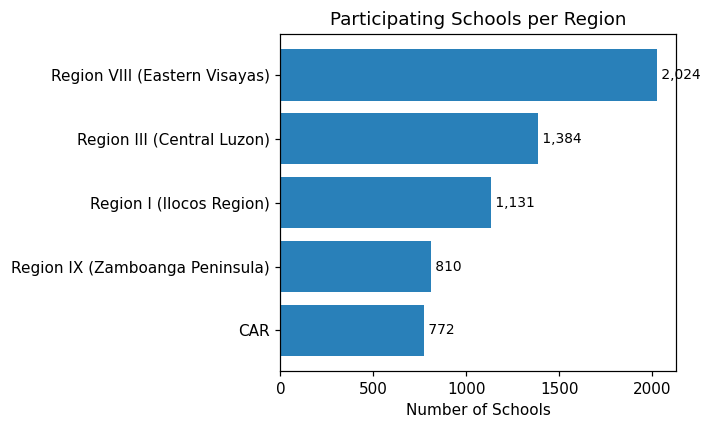

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4))
d = region_profile.sort_values("No_of_Schools", ascending=True)
ax.barh(d["Region"], d["No_of_Schools"], color="#2980b9")
ax.set_xlabel("Number of Schools")
ax.set_title("Participating Schools per Region")
for i, v in enumerate(d["No_of_Schools"]):
    ax.text(v, i, f" {v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "01_schools_per_region.png"), bbox_inches="tight")
plt.show()

This charts the number of schools per mother tongue, confirming Tagalog, Waray, and Sinugbuanong Binisaya as the three dominant languages by a wide margin.

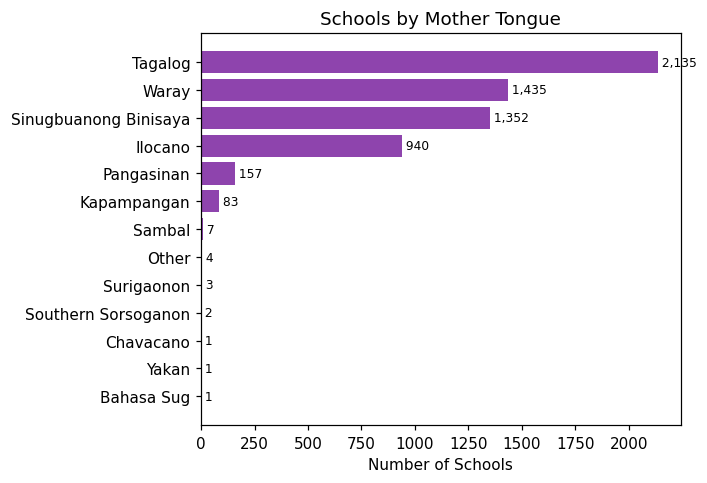

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
d = mt_profile.sort_values("No_of_Schools", ascending=True)
ax.barh(d["Mother_Tongue"], d["No_of_Schools"], color="#8e44ad")
ax.set_xlabel("Number of Schools")
ax.set_title("Schools by Mother Tongue")
for i, v in enumerate(d["No_of_Schools"]):
    ax.text(v, i, f" {v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "02_schools_by_mother_tongue.png"), bbox_inches="tight")
plt.show()

This shows the overall classification distribution as a pie chart, visually reinforcing that Partially Urban schools dominate the sample.

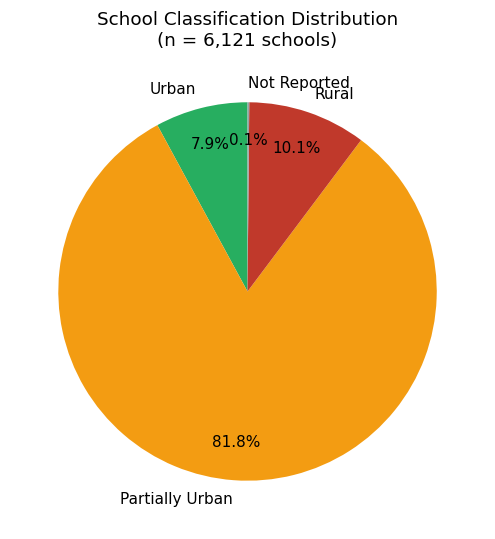

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5))
d = class_profile
colors = ["#27ae60", "#f39c12", "#c0392b", "#95a5a6"]
ax.pie(d["No_of_Schools"], labels=d["Classification"], autopct="%1.1f%%",
       colors=colors[: len(d)], startangle=90, pctdistance=0.8)
ax.set_title(f"School Classification Distribution\n(n = {n_schools:,} schools)")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "03_classification_pie.png"), bbox_inches="tight")
plt.show()

This builds a stacked bar chart showing the classification mix within each region, making it easy to see that CAR is far more rural than any other region while Region VIII and Region IX are almost entirely Partially Urban.

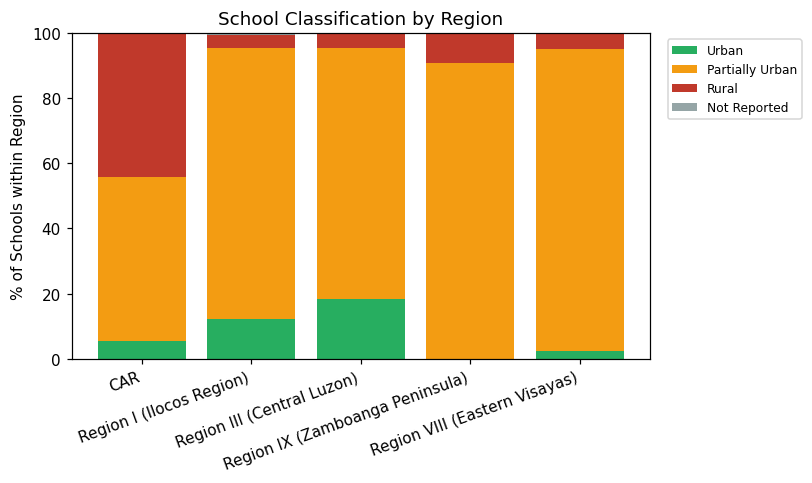

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_cols = [c for c in class_order if c in region_class_pct.columns]
bottom = np.zeros(len(region_class_pct))
bar_colors = {"Urban": "#27ae60", "Partially Urban": "#f39c12", "Rural": "#c0392b", "Not Reported": "#95a5a6"}
idx = region_class_pct.index
for c in plot_cols:
    vals = region_class_pct[c].values
    ax.bar(idx, vals, bottom=bottom, label=c, color=bar_colors.get(c))
    bottom += vals
ax.set_ylabel("% of Schools within Region")
ax.set_title("School Classification by Region")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "04_region_by_classification_stacked.png"), bbox_inches="tight")
plt.show()

This stacks the five proficiency levels per region, letting the reading outcome gap between regions be compared at a glance -- Region III's larger green (At Grade Level) segment and Region IX's larger red (Low Emerging) segment stand out clearly.

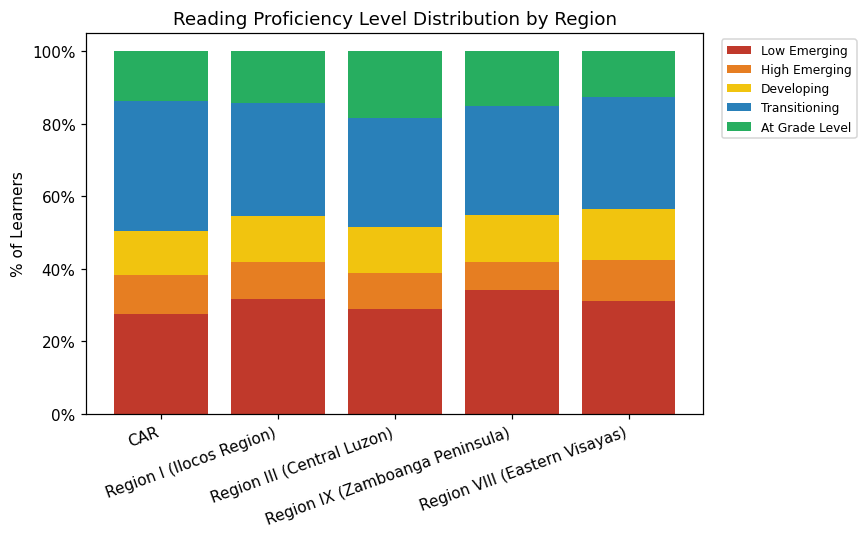

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
d = prof_by_region.set_index("Region")[LEVEL_ORDER]
bottom = np.zeros(len(d))
for level in LEVEL_ORDER:
    ax.bar(d.index, d[level], bottom=bottom, label=level, color=LEVEL_COLORS[level])
    bottom += d[level].values
ax.set_ylabel("% of Learners")
ax.set_title("Reading Proficiency Level Distribution by Region")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "05_proficiency_by_region.png"), bbox_inches="tight")
plt.show()

This produces the same type of stacked chart but grouped by school classification instead of region, showing that Urban schools have the largest At Grade Level share and Rural/Not Reported schools the smallest.

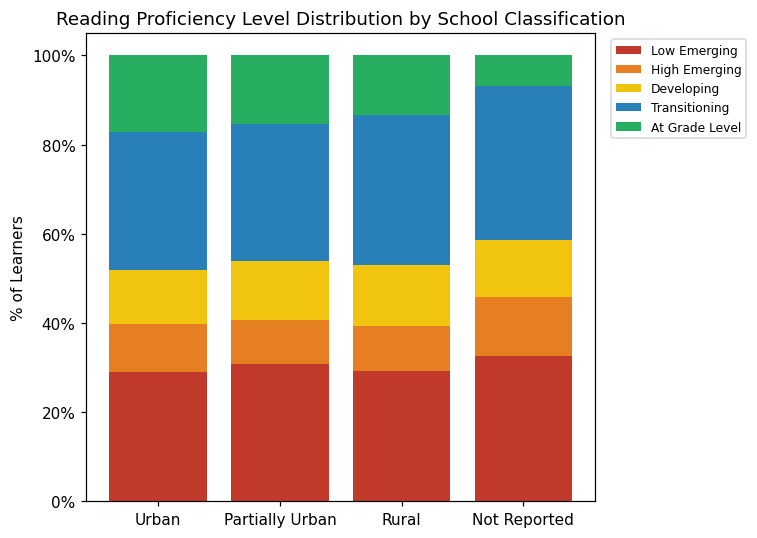

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
d = prof_by_class.set_index("Classification")[LEVEL_ORDER]
bottom = np.zeros(len(d))
for level in LEVEL_ORDER:
    ax.bar(d.index.astype(str), d[level], bottom=bottom, label=level, color=LEVEL_COLORS[level])
    bottom += d[level].values
ax.set_ylabel("% of Learners")
ax.set_title("Reading Proficiency Level Distribution by School Classification")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "06_proficiency_by_classification.png"), bbox_inches="tight")
plt.show()

This renders the national proficiency distribution as a donut chart, giving a single-glance summary of where all learners nationwide currently stand across the five reading levels.

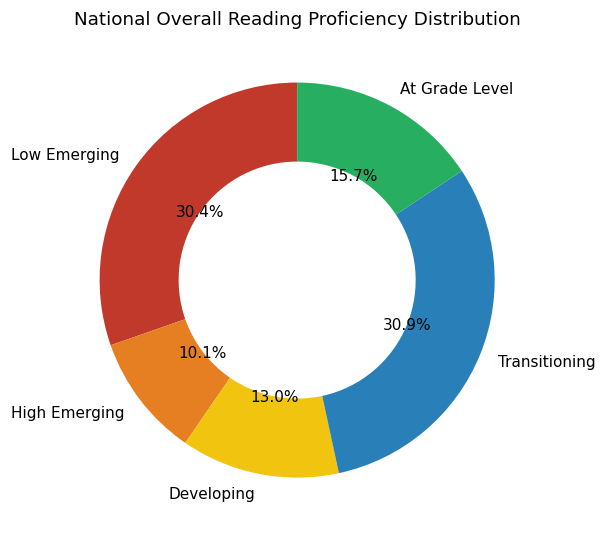

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.pie(national_pct.values, labels=national_pct.index, autopct="%1.1f%%",
       colors=[LEVEL_COLORS[l] for l in national_pct.index], startangle=90,
       wedgeprops=dict(width=0.4))
ax.set_title("National Overall Reading Proficiency Distribution")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "07_national_proficiency_donut.png"), bbox_inches="tight")
plt.show()

## Objective 3 — Correlation between Mother Tongue (L1), Filipino (L2), and English (L3) Proficiency, and Underlying Factors (PCA)

Grade 3 is the only grade level where all three languages -- Mother Tongue (L1), Filipino (L2), and English (L3) -- are assessed for the same learners, so it is the natural grade at which to test whether proficiency in the first language relates to proficiency in the second and third languages. To make the five categorical proficiency levels usable in a correlation and PCA, each school's result per grade-language combination is first converted into a single weighted numeric score, using Low Emerging = 1, High Emerging = 2, Developing = 3, Transitioning = 4, and At Grade Level = 5, then averaged across that school's learners. This gives one comparable "proficiency score" per school for each grade-language combination (Grade 1 MT, Grade 2 MT, Grade 2 Filipino, Grade 3 MT, Grade 3 Filipino, Grade 3 English), where a higher score means stronger reading proficiency.

In [ ]:
def weighted_score(prefix):
    low = df[f"{prefix}_low_emerging"]
    high = df[f"{prefix}_high_emerging"]
    dev = df[f"{prefix}_developing"]
    trans = df[f"{prefix}_transitioning"]
    at = df[f"{prefix}_at_grade_level"]
    tot = df[f"{prefix}_total"]
    return (1 * low + 2 * high + 3 * dev + 4 * trans + 5 * at) / tot

PREFIXES = ["g1_mt", "g2_mt", "g2_fil", "g3_mt", "g3_fil", "g3_eng"]
PREFIX_LABELS = {
    "g1_mt": "Grade 1 Mother Tongue (L1)", "g2_mt": "Grade 2 Mother Tongue (L1)",
    "g2_fil": "Grade 2 Filipino (L2)", "g3_mt": "Grade 3 Mother Tongue (L1)",
    "g3_fil": "Grade 3 Filipino (L2)", "g3_eng": "Grade 3 English (L3)",
}
for p in PREFIXES:
    df[p + "_score"] = weighted_score(p)

df[[p + "_score" for p in PREFIXES]].describe().round(2)

,g1_mt_score,g2_mt_score,g2_fil_score,g3_mt_score,g3_fil_score,g3_eng_score
count,6090.00,6060.00,6096.00,5920.00,6056.00,5918.00
mean,1.97,3.10,3.14,3.58,3.57,3.49
std,0.78,0.79,0.77,0.70,0.67,0.71
min,1.00,1.00,1.00,1.00,1.00,1.00
25%,1.40,2.57,2.65,3.19,3.21,3.08
50%,1.80,3.14,3.18,3.66,3.65,3.57
75%,2.37,3.67,3.70,4.00,4.00,4.00
max,5.00,5.00,5.00,5.00,5.00,5.00


### 3.1 Correlation between L1, L2, and L3 proficiency (Grade 3)

This restricts the dataset to the 5,778 schools that had test-takers in all three Grade 3 languages, then computes the Pearson correlation coefficient and p-value for every pair of L1 (Mother Tongue), L2 (Filipino), and L3 (English) proficiency scores. All three pairs show strong, statistically significant positive correlations (p < .001 in every case), meaning schools whose learners read well in their Mother Tongue also tend to read well in Filipino and English, and vice versa -- consistent with the linguistic-interdependence idea that strong first-language literacy transfers into additional-language literacy.

In [ ]:
from scipy.stats import pearsonr

g3 = df[(df["g3_mt_total"] > 0) & (df["g3_fil_total"] > 0) & (df["g3_eng_total"] > 0)].copy()
print(f"Schools with complete Grade 3 MT/Filipino/English data: {len(g3):,}")

pairs = [
    ("g3_mt_score", "g3_fil_score", "L1 (Mother Tongue) vs L2 (Filipino)"),
    ("g3_mt_score", "g3_eng_score", "L1 (Mother Tongue) vs L3 (English)"),
    ("g3_fil_score", "g3_eng_score", "L2 (Filipino) vs L3 (English)"),
]
corr_results = []
for a, b, label in pairs:
    r, p = pearsonr(g3[a], g3[b])
    corr_results.append({"Language Pair": label, "Pearson r": round(r, 4),
                          "p-value": p, "Significant (p<0.05)": p < 0.05, "N Schools": len(g3)})
corr_table = pd.DataFrame(corr_results)
corr_table

Schools with complete Grade 3 MT/Filipino/English data: 5,778


,Language Pair,Pearson r,p-value,Significant (p<0.05),N Schools
0,L1 (Mother Tongue) vs L2 (Filipino),0.9162,0.0,True,5778
1,L1 (Mother Tongue) vs L3 (English),0.8074,0.0,True,5778
2,L2 (Filipino) vs L3 (English),0.8325,0.0,True,5778


This visualizes the same relationships as a correlation heatmap across the three Grade 3 language scores, making the strength of each pairwise relationship easy to compare at a glance -- Mother Tongue and Filipino show the strongest relationship of the three pairs.

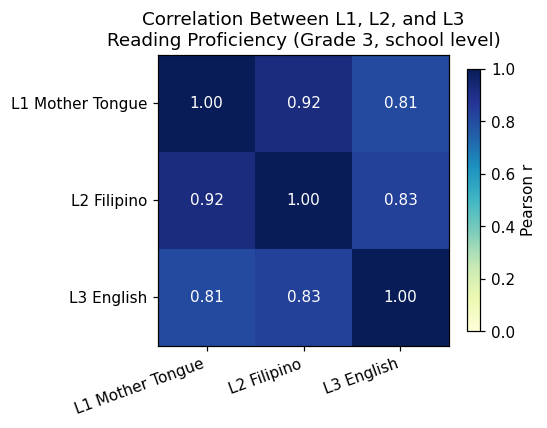

In [ ]:
corr_matrix = g3[["g3_mt_score", "g3_fil_score", "g3_eng_score"]].rename(
    columns={"g3_mt_score": "L1 Mother Tongue", "g3_fil_score": "L2 Filipino", "g3_eng_score": "L3 English"}
).corr()

fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(corr_matrix, vmin=0, vmax=1, cmap="YlGnBu")
ax.set_xticks(range(len(corr_matrix)))
ax.set_yticks(range(len(corr_matrix)))
ax.set_xticklabels(corr_matrix.columns, rotation=20, ha="right")
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if corr_matrix.iloc[i, j] > 0.6 else "black")
ax.set_title("Correlation Between L1, L2, and L3\nReading Proficiency (Grade 3, school level)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "08_l1_l2_l3_correlation_heatmap.png"), bbox_inches="tight")
plt.show()

This produces scatter plots for each language pair, with a fitted trend line, to visually confirm the positive linear relationship underlying each correlation coefficient reported above.

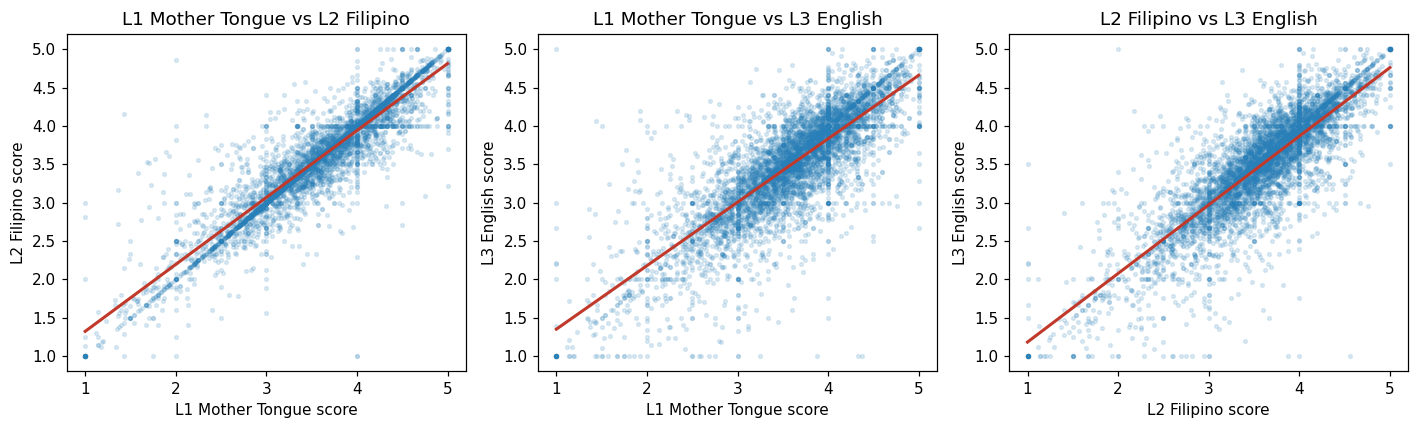

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_pairs = [("g3_mt_score", "g3_fil_score", "L1 Mother Tongue", "L2 Filipino"),
              ("g3_mt_score", "g3_eng_score", "L1 Mother Tongue", "L3 English"),
              ("g3_fil_score", "g3_eng_score", "L2 Filipino", "L3 English")]
for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, plot_pairs):
    ax.scatter(g3[xcol], g3[ycol], s=6, alpha=0.15, color="#2980b9")
    z = np.polyfit(g3[xcol], g3[ycol], 1)
    xs = np.linspace(g3[xcol].min(), g3[xcol].max(), 100)
    ax.plot(xs, np.polyval(z, xs), color="#c0392b", linewidth=2)
    ax.set_xlabel(f"{xlabel} score")
    ax.set_ylabel(f"{ylabel} score")
    ax.set_title(f"{xlabel} vs {ylabel}")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "09_l1_l2_l3_scatterplots.png"), bbox_inches="tight")
plt.show()

### 3.2 Underlying factors explaining variance in reading patterns (PCA)

To identify the underlying factors that best explain the variance in reading patterns across grades and languages, all six proficiency scores (Grade 1 MT, Grade 2 MT, Grade 2 Filipino, Grade 3 MT, Grade 3 Filipino, Grade 3 English) are standardized to a common scale and fed into a Principal Component Analysis. Standardizing is necessary so that no single grade-language score dominates the analysis purely because of scale.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

score_cols = [p + "_score" for p in PREFIXES]
total_cols = [p + "_total" for p in PREFIXES]
pca_mask = (df[total_cols] > 0).all(axis=1)
pca_data = df.loc[pca_mask, score_cols].copy()
print(f"Schools used in PCA (non-zero test-takers in all 6 grade-language combinations): {len(pca_data):,}")

X_scaled = StandardScaler().fit_transform(pca_data)
pca = PCA()
pca.fit(X_scaled)

pca_summary = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(score_cols))],
    "Eigenvalue": pca.explained_variance_.round(3),
    "Variance_Explained_%": (pca.explained_variance_ratio_ * 100).round(2),
    "Cumulative_%": (np.cumsum(pca.explained_variance_ratio_) * 100).round(2),
})
pca_summary

Schools used in PCA (non-zero test-takers in all 6 grade-language combinations): 5,726


,Component,Eigenvalue,Variance_Explained_%,Cumulative_%
0,PC1,3.718,61.96,61.96
1,PC2,1.195,19.92,81.88
2,PC3,0.717,11.94,93.82
3,PC4,0.212,3.54,97.36
4,PC5,0.083,1.38,98.73
5,PC6,0.076,1.27,100.00


This scree plot shows how much variance each successive principal component explains. The steep drop after the second component, together with the eigenvalue-greater-than-1 (Kaiser) rule, indicates that two components are sufficient to summarize the reading-pattern data meaningfully -- together they account for the large majority of total variance.

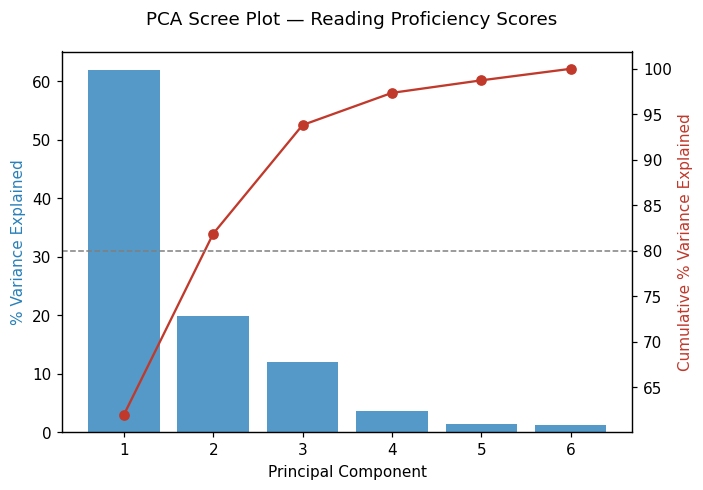

In [ ]:
fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
comps = np.arange(1, len(score_cols) + 1)
ax1.bar(comps, pca.explained_variance_ratio_ * 100, color="#2980b9", alpha=0.8, label="% Variance Explained")
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("% Variance Explained", color="#2980b9")
ax1.set_xticks(comps)
ax2 = ax1.twinx()
ax2.plot(comps, np.cumsum(pca.explained_variance_ratio_) * 100, color="#c0392b", marker="o", label="Cumulative %")
ax2.set_ylabel("Cumulative % Variance Explained", color="#c0392b")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
fig.suptitle("PCA Scree Plot — Reading Proficiency Scores")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "10_pca_scree_plot.png"), bbox_inches="tight")
plt.show()

This lays out the loadings -- how strongly each grade-language score contributes to each component -- so that each retained component can be interpreted. PC1 loads positively and fairly evenly on all six grade-language scores, so it reads as a general "overall reading proficiency" factor: schools with a high PC1 score simply read well across every grade and every language. PC2 loads positively on the Grade 1 and Grade 2 scores but negatively on all three Grade 3 scores, so it reads as a "grade-progression contrast" factor, separating schools whose relative strength is concentrated in the earlier grades from schools whose relative strength is concentrated in Grade 3.

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T, index=[PREFIX_LABELS[p] for p in PREFIXES],
    columns=[f"PC{i+1}" for i in range(len(score_cols))]
).round(3)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6
Grade 1 Mother Tongue (L1),0.253,0.436,0.863,-0.021,0.001,0.003
Grade 2 Mother Tongue (L1),0.408,0.462,-0.351,-0.014,-0.219,-0.670
Grade 2 Filipino (L2),0.411,0.452,-0.351,0.024,0.222,0.673
Grade 3 Mother Tongue (L1),0.451,-0.366,0.041,-0.474,-0.625,0.215
Grade 3 Filipino (L2),0.455,-0.370,0.045,-0.316,0.709,-0.228
Grade 3 English (L3),0.436,-0.348,0.068,0.821,-0.098,0.006


This charts the loadings of the first two components as horizontal bars, making the "general proficiency" interpretation of PC1 and the early-grade-vs-Grade-3 contrast interpretation of PC2 visually clear.

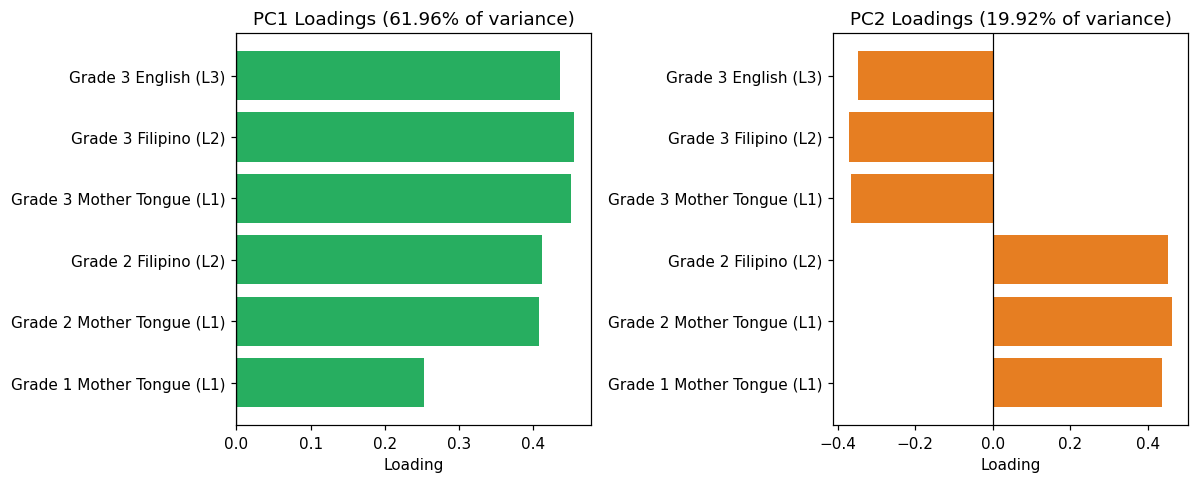

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = [PREFIX_LABELS[p] for p in PREFIXES]
for ax, pc, color in zip(axes, ["PC1", "PC2"], ["#27ae60", "#e67e22"]):
    vals = loadings[pc].values
    ax.barh(labels, vals, color=color)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{pc} Loadings ({pca_summary.loc[pca_summary['Component']==pc, 'Variance_Explained_%'].values[0]}% of variance)")
    ax.set_xlabel("Loading")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "11_pca_loadings.png"), bbox_inches="tight")
plt.show()

This adds each school's PC1 and PC2 scores back onto the dataset and plots them against each other, colored by region, to see whether the general-proficiency factor (PC1) or the grade-progression factor (PC2) separates schools along regional lines. Schools cluster fairly close together overall, but some regional separation along PC1 is visible, echoing the regional differences already seen in the proficiency-level tables in Objective 2.

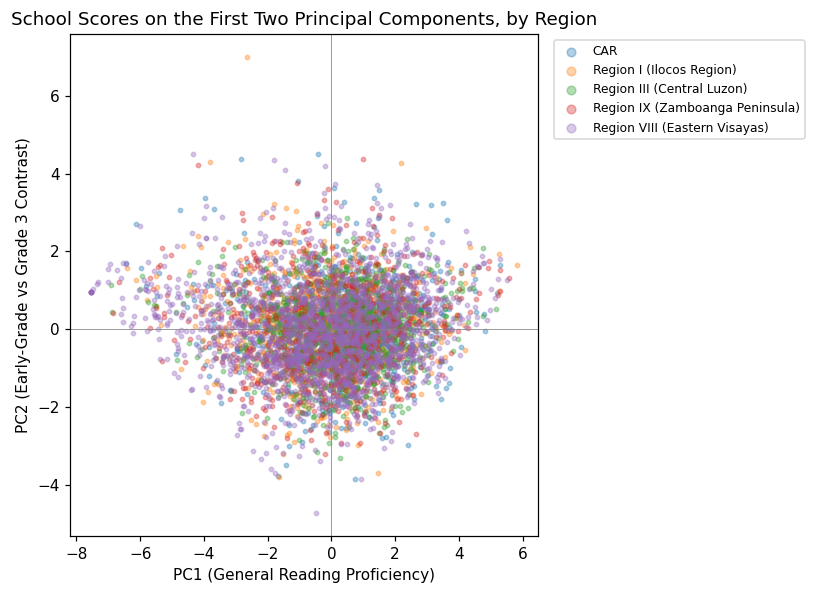

In [ ]:
pca_scores = pca.transform(X_scaled)[:, :2]
plot_df = df.loc[pca_mask, ["Region_Label"]].copy()
plot_df["PC1"] = pca_scores[:, 0]
plot_df["PC2"] = pca_scores[:, 1]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for region, sub in plot_df.groupby("Region_Label"):
    ax.scatter(sub["PC1"], sub["PC2"], s=8, alpha=0.35, label=region)
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlabel("PC1 (General Reading Proficiency)")
ax.set_ylabel("PC2 (Early-Grade vs Grade 3 Contrast)")
ax.set_title("School Scores on the First Two Principal Components, by Region")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, markerscale=2)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "12_pca_scatter_by_region.png"), bbox_inches="tight")
plt.show()

## Export all tables to Excel

This writes every table produced above into its own sheet in a single Excel workbook, so results can be shared or reviewed outside the notebook.

In [ ]:
def grouped_correlation_g3(data, group_col, x_col="g3_mt_score", y_col="g3_fil_score", min_n=10):
    """
    Calculates grouped correlations using your Grade 3 weighted scores.
    """
    rows = []
    for grp, sub in data.groupby(group_col, observed=True):
        # Drop rows missing either score for this specific pair
        sub_clean = sub[[x_col, y_col]].dropna()

        if len(sub_clean) >= min_n:
            r, p = pearsonr(sub_clean[x_col], sub_clean[y_col])
            rows.append({
                group_col: grp,
                "n_schools": len(sub_clean),
                "r": round(r, 3),
                "p_value": p,
                "significant": p < 0.05
            })
    return pd.DataFrame(rows).sort_values("r", ascending=False).reset_index(drop=True)

# --- RUN FOR L1 (MT) vs L2 (Filipino) ---
print("=" * 80)
print("G3 Mother Tongue (L1) vs G3 Filipino (L2) BY GROUP")
print("=" * 80)

print("\n--- BY REGION ---")
display(grouped_correlation_g3(df, "Region_Label", "g3_mt_score", "g3_fil_score"))

print("\n--- BY CLASSIFICATION ---")
display(grouped_correlation_g3(df, "Classification", "g3_mt_score", "g3_fil_score"))

print("\n--- BY LANGUAGE GROUP ---")
display(grouped_correlation_g3(df, "language", "g3_mt_score", "g3_fil_score"))

# --- RUN FOR L1 (MT) vs L3 (English) ---
print("\n" + "=" * 80)
print("G3 Mother Tongue (L1) vs G3 English (L3) BY GROUP")
print("=" * 80)

print("\n--- BY REGION ---")
display(grouped_correlation_g3(df, "Region_Label", "g3_mt_score", "g3_eng_score"))

print("\n--- BY CLASSIFICATION ---")
display(grouped_correlation_g3(df, "Classification", "g3_mt_score", "g3_eng_score"))

print("\n--- BY LANGUAGE GROUP ---")
display(grouped_correlation_g3(df, "language", "g3_mt_score", "g3_eng_score"))

G3 Mother Tongue (L1) vs G3 Filipino (L2) BY GROUP

--- BY REGION ---


,Region_Label,n_schools,r,p_value,significant
0,Region III (Central Luzon),1372,0.987,0.000000e+00,True
1,Region I (Ilocos Region),1069,0.922,0.000000e+00,True
2,Region VIII (Eastern Visayas),1962,0.916,0.000000e+00,True
3,Region IX (Zamboanga Peninsula),795,0.880,1.290138e-258,True
4,CAR,722,0.878,1.497939e-232,True



--- BY CLASSIFICATION ---


,Classification,n_schools,r,p_value,significant
0,Urban,480,0.952,1.115329e-247,True
1,Rural,591,0.919,6.882356e-240,True
2,Partially Urban,4840,0.914,0.000000e+00,True



--- BY LANGUAGE GROUP ---


...

,Region_Label,n_schools,r,p_value,significant
0,Region III (Central Luzon),1303,0.847,0.000000e+00,True
1,Region VIII (Eastern Visayas),1944,0.818,0.000000e+00,True
2,Region I (Ilocos Region),1057,0.802,1.047349e-238,True
3,CAR,689,0.794,1.782220e-150,True
4,Region IX (Zamboanga Peninsula),785,0.768,1.478073e-153,True



--- BY CLASSIFICATION ---


,Classification,n_schools,r,p_value,significant
0,Rural,566,0.819,5.518241e-138,True
1,Urban,476,0.818,6.968523e-116,True
2,Partially Urban,4727,0.805,0.000000e+00,True



--- BY LANGUAGE GROUP ---


,language,n_schools,r,p_value,significant
0,Tagalog,2022,0.822,0.000000e+00,True
1,Kapampangan,76,0.815,3.204554e-19,True
2,Pangasinan,151,0.811,1.781843e-36,True
3,Waray,1381,0.809,1.943654e-320,True
4,Ilocano,828,0.808,4.670511e-192,True
5,Sinugbuanong Binisaya,1301,0.788,5.684543e-276,True


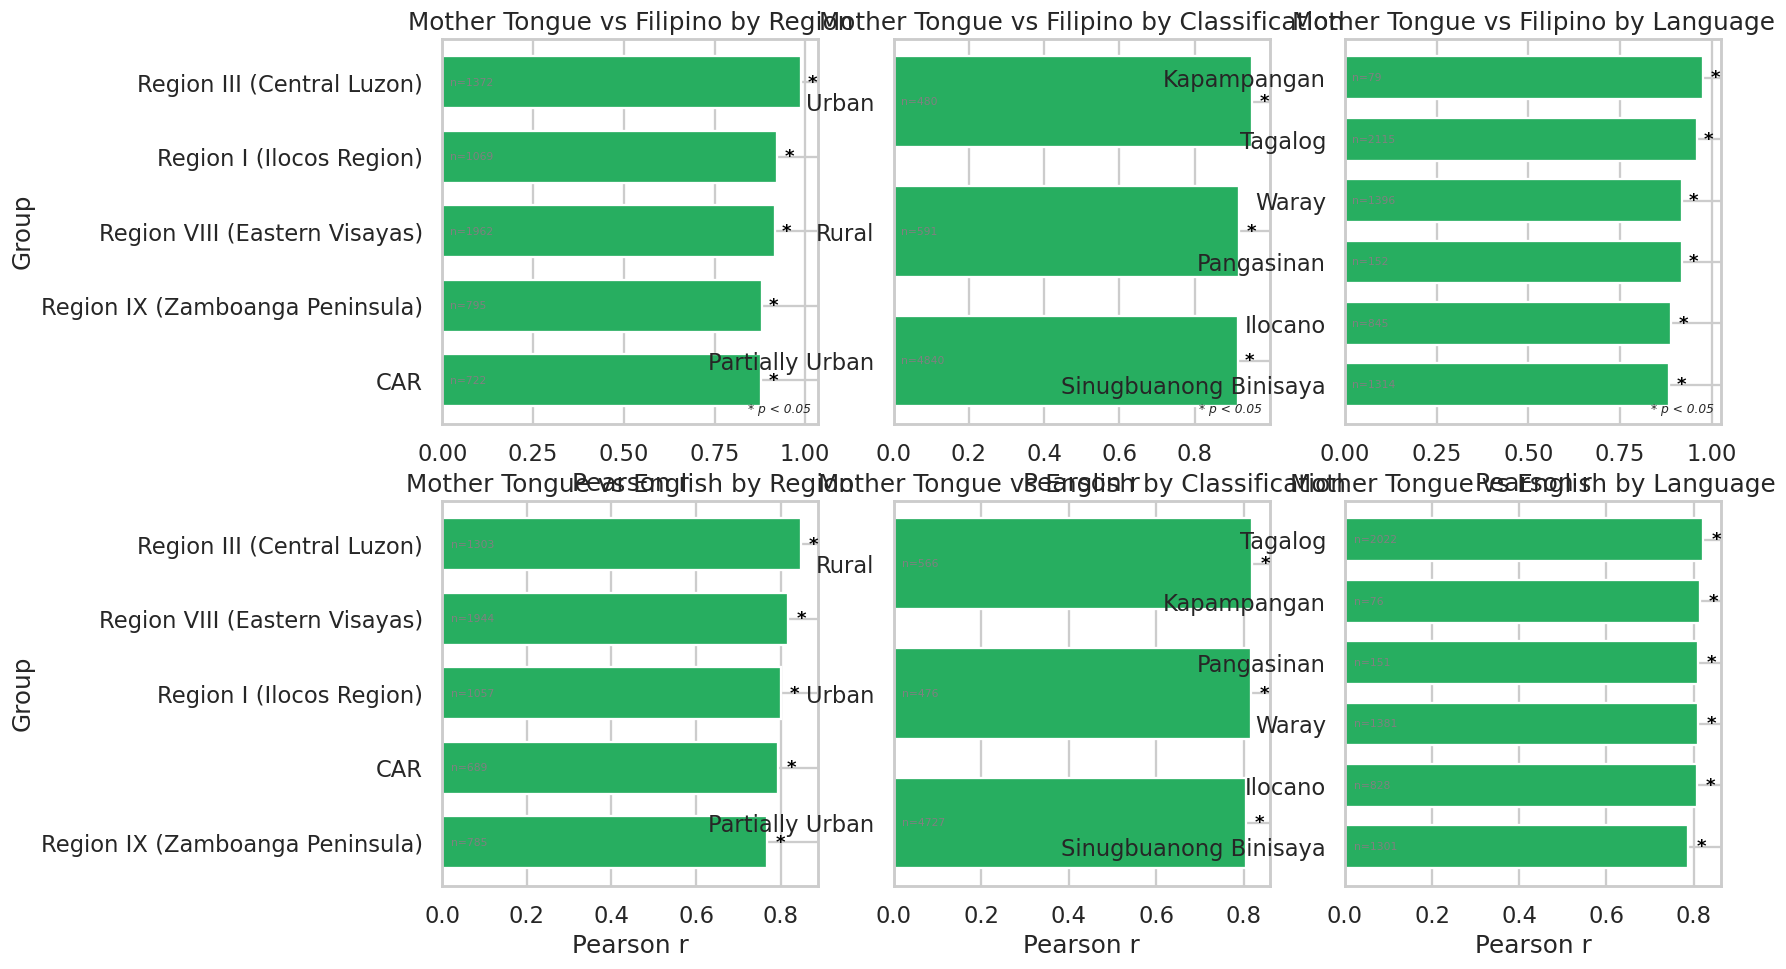

In [ ]:
# =============================================================================
# VISUALIZATION: GROUPED CORRELATIONS
# =============================================================================

# Collect the grouped correlation results for plotting
corr_results = {}
for pair, x, y in [('L1_L2', 'g3_mt_score', 'g3_fil_score'), ('L1_L3', 'g3_mt_score', 'g3_eng_score')]:
    corr_results[pair] = {}
    for group_col, group_label in [('Region_Label', 'Region'), ('Classification', 'Classification'), ('language', 'Language')]:
        df_corr = grouped_correlation_g3(df, group_col, x, y)
        corr_results[pair][group_label] = df_corr

# Function to plot a single subplot
def plot_corr_subplot(ax, df_corr, group_col, title):
    """Bar chart of correlation coefficients for a grouping variable."""
    df_plot = df_corr.sort_values('r', ascending=True)  # ascending for horizontal bars (top = highest)
    y_pos = np.arange(len(df_plot))
    colors = ['#27ae60' if r > 0 else '#c0392b' for r in df_plot['r']]
    ax.barh(y_pos, df_plot['r'], color=colors, height=0.7)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot[group_col])
    ax.set_xlabel('Pearson r')
    ax.set_title(title)
    # Add significance stars and sample size
    for i, (idx, row) in enumerate(df_plot.iterrows()):
        x_offset = 0.02 * (1 if row['r'] >= 0 else -1)
        if row['significant']:
            ax.text(row['r'] + x_offset, i, '*', va='center', fontsize=12, color='black', fontweight='bold')
        ax.text(0.02, i, f"n={row['n_schools']}", va='center', fontsize=7, color='gray')

# Create a 2x3 figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
pair_titles = ['Mother Tongue vs Filipino', 'Mother Tongue vs English']
group_names = ['Region', 'Classification', 'Language'] # Changed 'Mother Tongue' to 'Language'
# Mapping from display name to actual column name in the correlation dataframes
group_col_map = {'Region': 'Region_Label', 'Classification': 'Classification', 'Language': 'language'} # Changed 'Mother Tongue' to 'Language'

for row, pair in enumerate(['L1_L2', 'L1_L3']):
    for col, group in enumerate(group_names):
        ax = axes[row, col]
        df_corr = corr_results[pair][group]
        group_col = group_col_map[group] # This will now correctly map 'Language' to 'language'
        plot_corr_subplot(ax, df_corr, group_col, f"{pair_titles[row]} by {group}")
        if col == 0:
            ax.set_ylabel('Group')
        if row == 0:
            # Add note about significance
            ax.annotate('* p < 0.05', xy=(0.98, 0.02), xycoords='axes fraction',
                        ha='right', va='bottom', fontsize=8, style='italic')



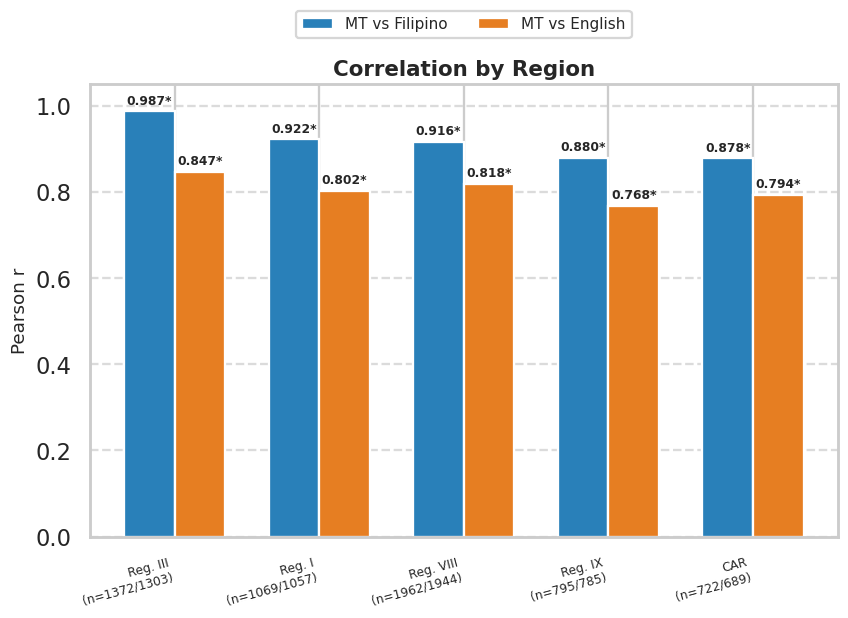

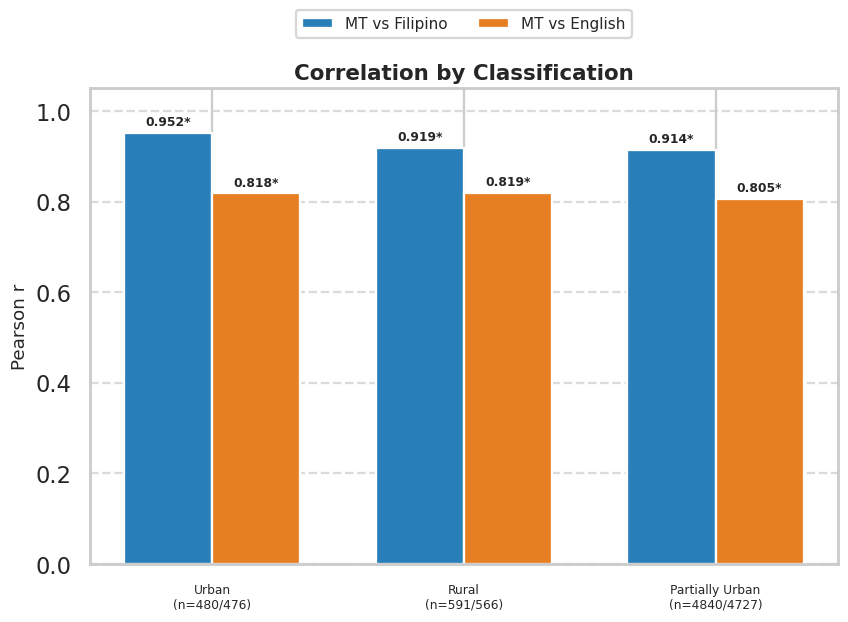

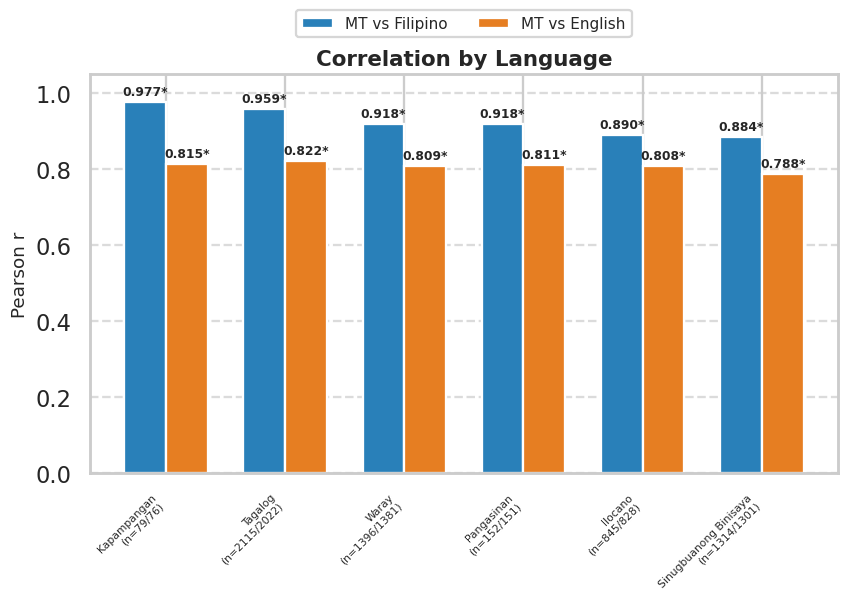

Individual charts saved successfully.


In [ ]:
# =============================================================================
# INDIVIDUAL CHARTS FOR GROUPED CORRELATIONS (WITH LEGEND ABOVE)
# =============================================================================

import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)

# The corr_results dictionary is already computed earlier in your notebook.
# We'll create separate figures for each grouping variable.

grouping_vars = {
    'Region': ('Region_Label', corr_results['L1_L2']['Region']),
    'Classification': ('Classification', corr_results['L1_L2']['Classification']),
    'Language': ('language', corr_results['L1_L2']['Language'])
}

# Loop over each grouping variable to create an individual chart
for group_label, (col_name, df_l1l2) in grouping_vars.items():
    # Create a new figure for this group
    fig, ax = plt.subplots(figsize=(8, 6))

    # Get corresponding L1_L3 data
    df_l1l3 = corr_results['L1_L3'][group_label]

    # Merge and sort by L1_L2 r descending
    merged = pd.merge(df_l1l2, df_l1l3, on=col_name, suffixes=('_l1l2', '_l1l3'))
    merged = merged.sort_values('r_l1l2', ascending=False)

    groups = merged[col_name].values
    r_l1l2 = merged['r_l1l2'].values
    r_l1l3 = merged['r_l1l3'].values
    n_l1l2 = merged['n_schools_l1l2'].values
    n_l1l3 = merged['n_schools_l1l3'].values
    sig_l1l2 = merged['significant_l1l2'].values
    sig_l1l3 = merged['significant_l1l3'].values

    x = np.arange(len(groups))
    width = 0.35

    # Plot bars
    bars1 = ax.bar(x - width/2, r_l1l2, width, label='MT vs Filipino', color='#2980b9')
    bars2 = ax.bar(x + width/2, r_l1l3, width, label='MT vs English', color='#e67e22')

    # Add value labels on bars
    for bar, rval, sig in zip(bars1, r_l1l2, sig_l1l2):
        height = bar.get_height()
        label = f'{rval:.3f}'
        if sig:
            label += '*'
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, label,
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    for bar, rval, sig in zip(bars2, r_l1l3, sig_l1l3):
        height = bar.get_height()
        label = f'{rval:.3f}'
        if sig:
            label += '*'
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, label,
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    # Build tick labels with sample sizes (shorten region names if needed)
    tick_labels = []
    for g, n1, n2 in zip(groups, n_l1l2, n_l1l3):
        if group_label == 'Region':
            # Shorten region names
            g_short = g.replace('Region ', 'Reg. ').replace(' (Central Luzon)', '').replace(' (Ilocos Region)', '').replace(' (Eastern Visayas)', '').replace(' (Zamboanga Peninsula)', '')
        else:
            g_short = g
        tick_labels.append(f'{g_short}\n(n={n1}/{n2})')

    ax.set_xticks(x)
    # Rotate labels for Language and Region
    if group_label == 'Language':
        ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
    elif group_label == 'Region':
        ax.set_xticklabels(tick_labels, rotation=15, ha='right', fontsize=8)
    else:  # Classification
        ax.set_xticklabels(tick_labels, rotation=0, ha='center', fontsize=8)

    # Axes limits and labels
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Pearson r', fontsize=12)
    ax.set_title(f'Correlation by {group_label}', fontweight='bold', fontsize=14)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Add legend ABOVE the chart
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize=10, frameon=True)



    plt.tight_layout(rect=[0, 0.05, 1, 1.05])

    # Save individual chart
    filename = f"correlations_by_{group_label.lower()}.png"
    plt.savefig(os.path.join(CHART_DIR, filename), bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)  # Close to free memory

print("Individual charts saved successfully.")

In [ ]:
OUT_XLSX = "crla_analysis_output.xlsx"
with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    summary = pd.DataFrame({
        "Metric": ["Total Participating Schools", "Total Learners Tested", "Number of Regions",
                   "Number of Mother Tongues", "Number of Classifications (excl. Not Reported)"],
        "Value": [n_schools, int(n_learners), df["Region_Label"].nunique(),
                  df["language"].nunique(), len([c for c in class_order if c != "Not Reported"])],
    })
    summary.to_excel(writer, sheet_name="Summary", index=False)
    region_profile.to_excel(writer, sheet_name="1.1 Region Profile", index=False)
    mt_profile.to_excel(writer, sheet_name="1.1 Mother Tongue Profile", index=False)
    region_mt_crosstab.to_excel(writer, sheet_name="1.1 Region x MotherTongue")
    dominant_mt.to_excel(writer, sheet_name="1.1 Dominant MT per Region", index=False)
    class_profile.to_excel(writer, sheet_name="1.2 Classification Profile", index=False)
    region_class_crosstab.to_excel(writer, sheet_name="1.2 Region x Classification")
    region_class_pct.to_excel(writer, sheet_name="1.2 RegionxClass (Pct)")
    prof_by_region.to_excel(writer, sheet_name="2. Proficiency by Region", index=False)
    prof_by_class.to_excel(writer, sheet_name="2. Proficiency by Classif", index=False)
    prof_by_region_class.to_excel(writer, sheet_name="2. Proficiency RegionxClass", index=False)
    national_pct.to_frame("Percent").to_excel(writer, sheet_name="2. National Overall")
    corr_table.to_excel(writer, sheet_name="3. L1-L2-L3 Correlation", index=False)
    pca_summary.to_excel(writer, sheet_name="3. PCA Variance Summary", index=False)
    loadings.to_excel(writer, sheet_name="3. PCA Loadings")

print("Saved:", OUT_XLSX)

Saved: crla_analysis_output.xlsx


Schools used for clustering: 5,726

Cluster sizes:
  Cluster 0: 2538 schools (44.3%)
  Cluster 1: 3188 schools (55.7%)


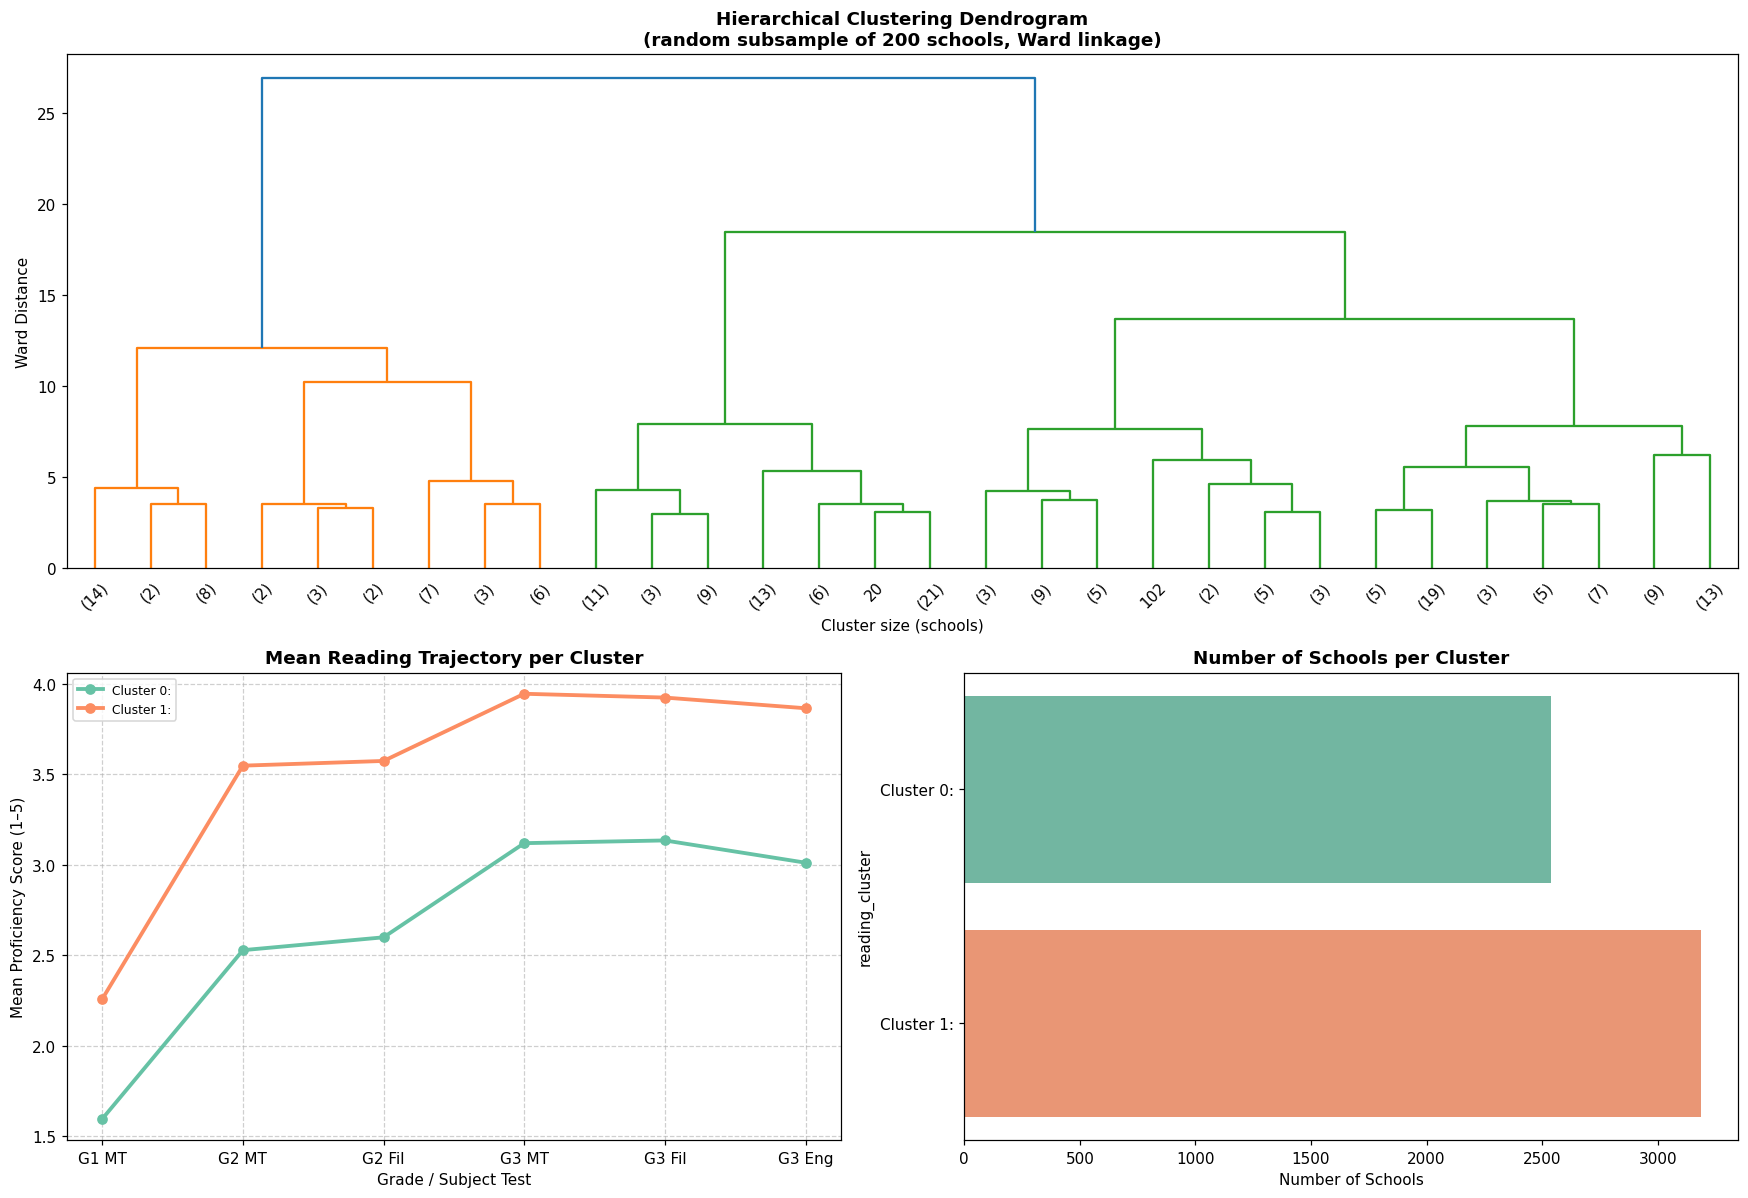

In [ ]:
# =============================================================================
# OBJECTIVE 5 — NATURAL PERFORMANCE CLUSTERS FROM GRADE 1→3 TRAJECTORIES
# =============================================================================

# ---- Prepare data ----
score_cols = [p + "_score" for p in PREFIXES]
total_cols = [p + "_total" for p in PREFIXES]
valid_mask = (df[total_cols] > 0).all(axis=1)
cluster_df = df.loc[valid_mask, score_cols].copy()
print(f"Schools used for clustering: {len(cluster_df):,}")

# Standardise the six proficiency scores
scaler = StandardScaler()
traj_scaled = scaler.fit_transform(cluster_df)

# ---- Run hierarchical clustering (Ward linkage, 3 clusters) ----
n_clusters = 2
agg_clust = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
cluster_labels = agg_clust.fit_predict(traj_scaled)
print("\nCluster sizes:")
for cl in np.unique(cluster_labels):
    count = (cluster_labels == cl).sum()
    print(f"  Cluster {cl}: {count} schools ({count/len(cluster_labels)*100:.1f}%)")

# Add cluster labels to the original df
df.loc[valid_mask, "reading_cluster"] = cluster_labels

# ---- Compute cluster profiles (mean score per stage) ----
cluster_profile = df.loc[valid_mask].groupby("reading_cluster")[score_cols].mean().round(3)
cluster_profile.columns = [PREFIX_LABELS[p] for p in PREFIXES]
cluster_profile.insert(0, "n_schools", df.loc[valid_mask]["reading_cluster"].value_counts().sort_index())

# ---- Dendrogram (subsample for readability) ----
sample_size = 200
rng = np.random.default_rng(42)
n_rows = traj_scaled.shape[0]
sample_idx = rng.choice(n_rows, size=min(sample_size, n_rows), replace=False)
linkage_matrix = linkage(traj_scaled[sample_idx], method="ward")

# Rebuilt figure using GridSpec in the correct order
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1])

# Dendrogram (top row)
ax0 = fig.add_subplot(gs[0, :])
dendrogram(linkage_matrix, truncate_mode="lastp", p=30, show_leaf_counts=True, ax=ax0)
ax0.set_title("Hierarchical Clustering Dendrogram\n(random subsample of 200 schools, Ward linkage)", fontweight="bold")
ax0.set_xlabel("Cluster size (schools)")
ax0.set_ylabel("Ward Distance")

# ---- Trajectory line plot (bottom left) ----
ax1 = fig.add_subplot(gs[1, 0])
stage_labels = ["G1 MT", "G2 MT", "G2 Fil", "G3 MT", "G3 Fil", "G3 Eng"]
cluster_names = {
    0: "Cluster 0:",
    1: "Cluster 1:",
    2: "Cluster 2:",
    3: "Cluster 3:"
}
palette_c = sns.color_palette("Set2", n_colors=n_clusters)
for cl in sorted(df.loc[valid_mask, "reading_cluster"].unique()):
    # Map cluster index to columns for plotting
    means = cluster_profile.loc[cl, [PREFIX_LABELS[p] for p in PREFIXES]]
    ax1.plot(stage_labels, means, marker="o", linewidth=2.5,
             label=cluster_names.get(cl, f"Cluster {cl}"), color=palette_c[int(cl)])
ax1.set_title("Mean Reading Trajectory per Cluster", fontweight="bold")
ax1.set_ylabel("Mean Proficiency Score (1–5)")
ax1.set_xlabel("Grade / Subject Test")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(True, linestyle="--", alpha=0.6)

# ---- Cluster sizes (bottom right) ----
ax2 = fig.add_subplot(gs[1, 1])
cluster_sizes = df.loc[valid_mask]["reading_cluster"].value_counts().sort_index()
sizes_named = cluster_sizes.rename(index=cluster_names)
sns.barplot(x=sizes_named.values, y=sizes_named.index.astype(str), hue=sizes_named.index.astype(str),
            legend=False, palette=palette_c, ax=ax2)
ax2.set_title("Number of Schools per Cluster", fontweight="bold")
ax2.set_xlabel("Number of Schools")

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "13_hierarchical_clusters.png"), bbox_inches="tight")
plt.show()


COMPOSITION OF CLUSTERS BY REGION
Values are percentages of schools within each cluster (columns sum to 100%).
The 'Total (%)' row shows the overall proportion of schools in each cluster.

reading_cluster                  Cluster 0 (Struggling)  Cluster 1 (Strong)
Region_Label                                                               
CAR                                                 8.7                14.1
Region I (Ilocos Region)                           20.5                16.6
Region III (Central Luzon)                         20.1                24.8
Region IX (Zamboanga Peninsula)                    14.1                13.2
Region VIII (Eastern Visayas)                      36.5                31.3
Total (%)                                          44.3                55.7




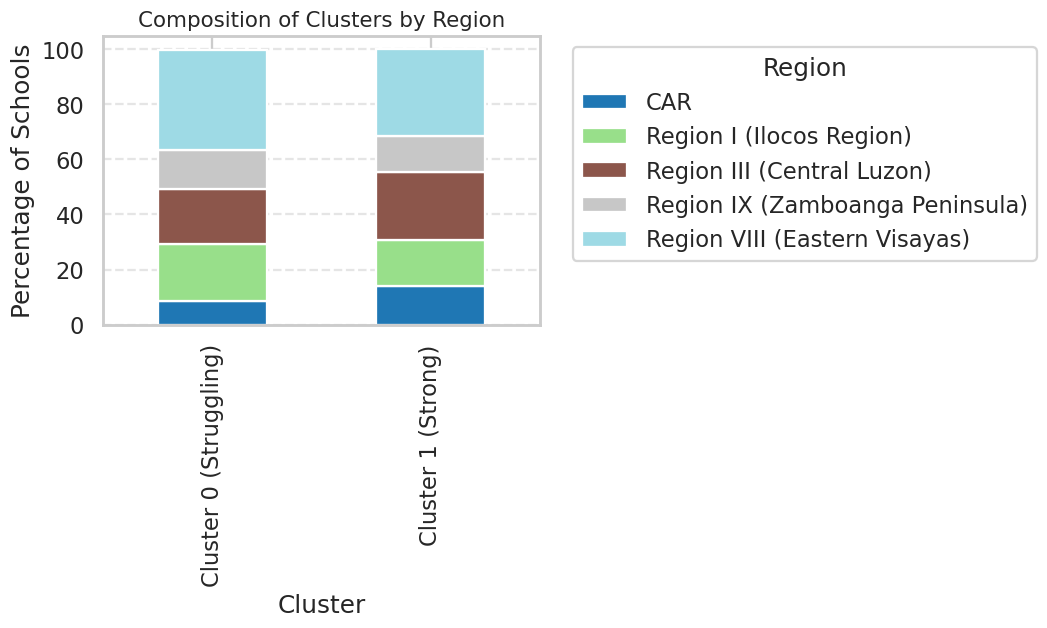


COMPOSITION OF CLUSTERS BY MOTHER TONGUE
Values are percentages of schools within each cluster (columns sum to 100%).
The 'Total (%)' row shows the overall proportion of schools in each cluster.

reading_cluster        Cluster 0 (Struggling)  Cluster 1 (Strong)
language                                                         
Bahasa Sug                                0.0                 0.0
Chavacano                                 0.0                 0.0
Ilocano                                  14.8                13.9
Kapampangan                               0.9                 1.7
Other                                     0.0                 0.1
Pangasinan                                3.0                 2.3
Sambal                                    0.3                 0.0
Sinugbuanong Binisaya                    20.4                24.3
Southern Sorsoganon                       0.0                 0.0
Surigaonon                                0.0                 0.1
Tagalog    

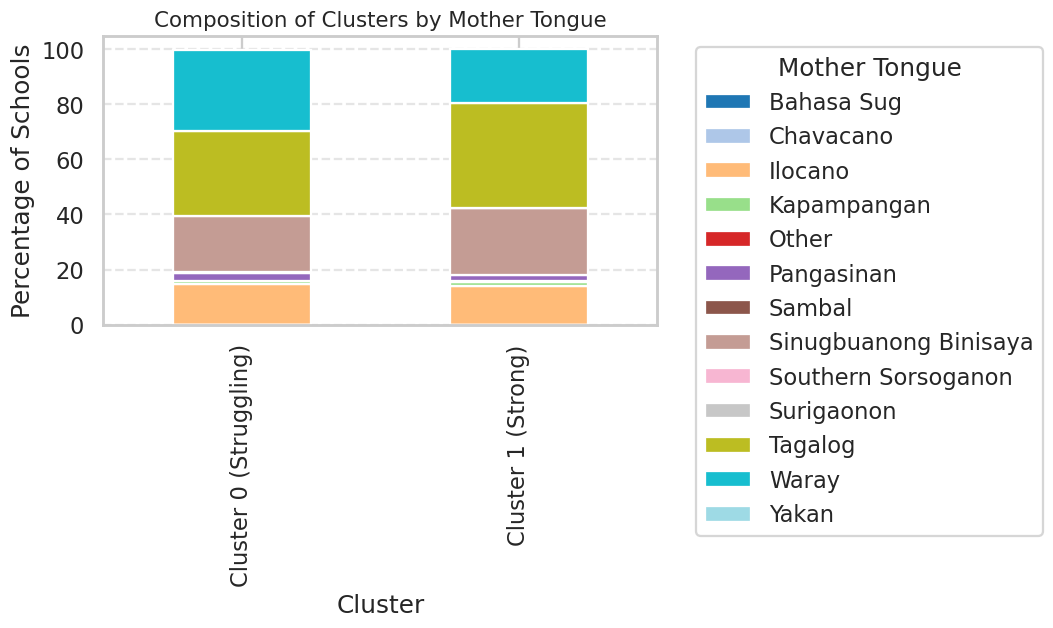


COMPOSITION OF CLUSTERS BY SCHOOL CLASSIFICATION
Values are percentages of schools within each cluster (columns sum to 100%).
The 'Total (%)' row shows the overall proportion of schools in each cluster.

reading_cluster  Cluster 0 (Struggling)  Cluster 1 (Strong)
Classification                                             
Not Reported                        0.2                 0.2
Partially Urban                    82.9                81.2
Rural                               8.0                10.8
Urban                               8.9                 7.8
Total (%)                          44.3                55.7




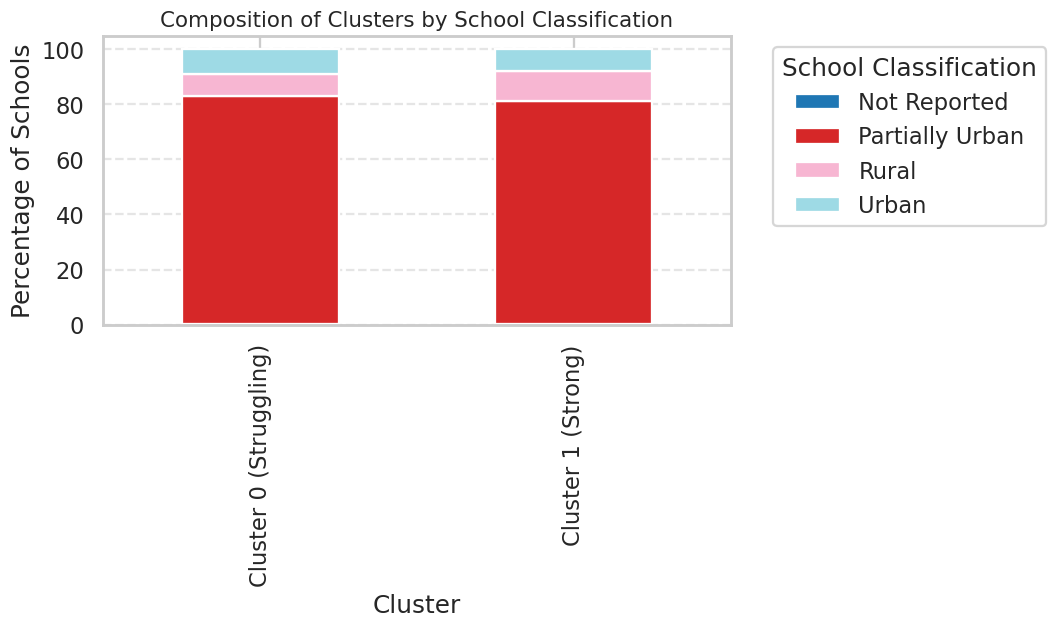


COMPOSITION OF CLUSTERS BY REGION (SHORT)
Values are percentages of schools within each cluster (columns sum to 100%).
The 'Total (%)' row shows the overall proportion of schools in each cluster.

reading_cluster  Cluster 0 (Struggling)  Cluster 1 (Strong)
region                                                     
CAR                                 8.7                14.1
Region I                           20.5                16.6
Region III                         20.1                24.8
Region IX                          14.1                13.2
Region VIII                        36.5                31.3
Total (%)                          44.3                55.7




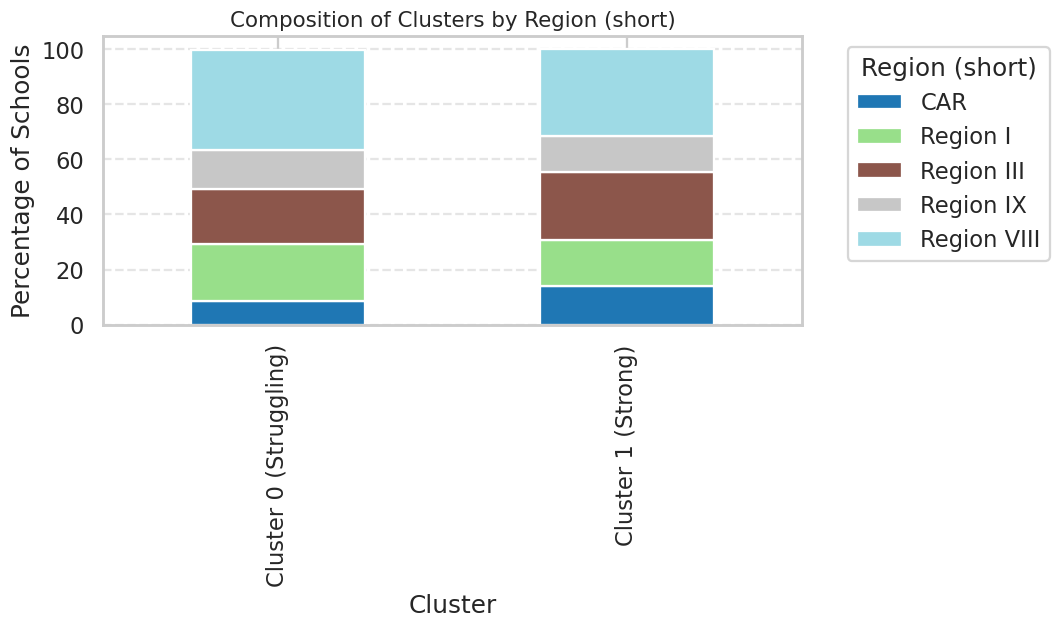

In [ ]:
# =============================================================================
# COMPOSITION OF CLUSTERS BY REGION, LANGUAGE, AND CLASSIFICATION
# =============================================================================

# Ensure the cluster labels are available in the main dataframe
# (already done: df.loc[valid_mask, "reading_cluster"] = cluster_labels)

# Define a helper function to create tables and plots
def cluster_composition(df, valid_mask, cluster_col, category_col, category_label):
    """
    Computes and visualises the composition of clusters by a categorical variable.

    Parameters:
    - df: full dataframe
    - valid_mask: boolean mask for schools used in clustering
    - cluster_col: column name that holds the cluster labels (e.g., 'reading_cluster')
    - category_col: column name for the grouping variable (e.g., 'Region_Label')
    - category_label: label for the category (e.g., 'Region')
    """
    # Subset to valid rows
    sub = df.loc[valid_mask, [cluster_col, category_col]].dropna()

    # ---- Table: percentage of each category within each cluster ----
    # (rows sum to 100% within each cluster column)
    cross_tab = pd.crosstab(sub[category_col], sub[cluster_col], normalize='columns') * 100
    cross_tab = cross_tab.round(1)

    # Add a 'Total' row showing the overall cluster size percentages
    total_pct = sub[cluster_col].value_counts(normalize=True) * 100
    cross_tab.loc['Total (%)'] = total_pct.sort_index().round(1)

    # Rename cluster columns for clarity (if 0 and 1)
    cluster_names = {0: 'Cluster 0 (Struggling)', 1: 'Cluster 1 (Strong)'} if len(cross_tab.columns)==2 else None
    if cluster_names:
        cross_tab = cross_tab.rename(columns=cluster_names)

    print(f"\n{'='*60}")
    print(f"COMPOSITION OF CLUSTERS BY {category_label.upper()}")
    print(f"{'='*60}")
    print(f"Values are percentages of schools within each cluster (columns sum to 100%).")
    print(f"The 'Total (%)' row shows the overall proportion of schools in each cluster.\n")
    print(cross_tab)
    print("\n")

    # ---- Plot: stacked bar chart ----
    # Remove the total row for plotting
    plot_data = cross_tab.drop('Total (%)')

    fig, ax = plt.subplots(figsize=(10, 6))
    plot_data.T.plot(kind='bar', stacked=True, ax=ax, cmap='tab20')
    ax.set_title(f'Composition of Clusters by {category_label}', fontsize=14)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Percentage of Schools')
    ax.legend(title=category_label, bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    # Save the figure
    filename = f"cluster_composition_by_{category_col}.png"
    plt.savefig(os.path.join(CHART_DIR, filename), bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)

    return cross_tab

# -----------------------------------------------------------------------------
# 1. Composition by Region (using the full region labels, e.g., 'Region III (Central Luzon)')
# -----------------------------------------------------------------------------
region_table = cluster_composition(
    df=df,
    valid_mask=valid_mask,
    cluster_col='reading_cluster',
    category_col='Region_Label',
    category_label='Region'
)

# -----------------------------------------------------------------------------
# 2. Composition by Language (Mother Tongue)
# -----------------------------------------------------------------------------
language_table = cluster_composition(
    df=df,
    valid_mask=valid_mask,
    cluster_col='reading_cluster',
    category_col='language',
    category_label='Mother Tongue'
)

# -----------------------------------------------------------------------------
# 3. Composition by School Classification (Urban, Rural, Partially Urban)
# -----------------------------------------------------------------------------
# Filter out 'Not Reported' if you wish, but we'll include them for completeness.
classification_table = cluster_composition(
    df=df,
    valid_mask=valid_mask,
    cluster_col='reading_cluster',
    category_col='Classification',
    category_label='School Classification'
)

# -----------------------------------------------------------------------------
# 4. (Optional) Composition by Grouped Language (if you created a 'language_grouped' column)
# -----------------------------------------------------------------------------
# If you have the 'language_grouped' column (e.g., from earlier preprocessing), use it.
# Uncomment the following lines if you have that column.
#
# if 'language_grouped' in df.columns:
#     grouped_lang_table = cluster_composition(
#         df=df,
#         valid_mask=valid_mask,
#         cluster_col='reading_cluster',
#         category_col='language_grouped',
#         category_label='Language Group (Major Only)'
#     )

# -----------------------------------------------------------------------------
# 5. (Optional) Composition by original 'region' (shorter names, e.g., 'CAR', 'Region I')
# -----------------------------------------------------------------------------
if 'region' in df.columns:
    region_short_table = cluster_composition(
        df=df,
        valid_mask=valid_mask,
        cluster_col='reading_cluster',
        category_col='region',
        category_label='Region (short)'
    )

In [ ]:
# --- DETERMINE OPTIMAL K ---
silhouette_scores = []
K_range = range(2, 9)  # Test cluster sizes from 2 to 8

print("\nCalculating Silhouette Scores to find optimal number of clusters...")
for k in K_range:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(traj_scaled)
    score = silhouette_score(traj_scaled, labels)
    silhouette_scores.append(score)
    print(f"  k={k}: Silhouette = {score:.4f}")

best_k = K_range[np.argmax(silhouette_scores)]
print(f"\n>> Optimal number of clusters (highest silhouette score): {best_k}")


n_clusters = best_k
# --------------------------

agg_clust = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
cluster_labels = agg_clust.fit_predict(traj_scaled)


Calculating Silhouette Scores to find optimal number of clusters...
  k=2: Silhouette = 0.2807
  k=3: Silhouette = 0.2021
  k=4: Silhouette = 0.1514
  k=5: Silhouette = 0.1434
  k=6: Silhouette = 0.1228
  k=7: Silhouette = 0.1295
  k=8: Silhouette = 0.1389

>> Optimal number of clusters (highest silhouette score): 2


# R6-Logistic Regression

- To what extent does the strength of early Mother Tongue foundations predict a school's overall transition success to "At Grade Level" status, and which demographic features serve as the strongest predictors in a Logistic Regression model?

MODEL 1: ISOLATING MOTHER TONGUE EFFECT ON HIGH ENGLISH PROFICIENCY
Schools used: 5,890
Original Class Distribution:
is_high_english
Not High English (0)    3207
High English (1)        2683
Name: count, dtype: int64
--------------------------------------------------
MODEL PERFORMANCE: MOTHER TONGUE EFFECT ON HIGH ENGLISH PROFICIENCY
Overall Accuracy: 55.52%

Classification Report:
                      precision    recall  f1-score   support

Not High English (0)     0.5967    0.5632    0.5795       641
    High English (1)     0.5113    0.5456    0.5279       537

            accuracy                         0.5552      1178
           macro avg     0.5540    0.5544    0.5537      1178
        weighted avg     0.5578    0.5552    0.5560      1178

ODDS RATIOS: EFFECT OF MOTHER TONGUE ON HIGH ENGLISH

 Interpretation Guide:
   * OR > 1.0 = INCREASES chance of High English Proficiency
   * OR < 1.0 = DECREASES chance / Risk Factor
   * OR = 1.0 = Baseline language (Reference group)

  

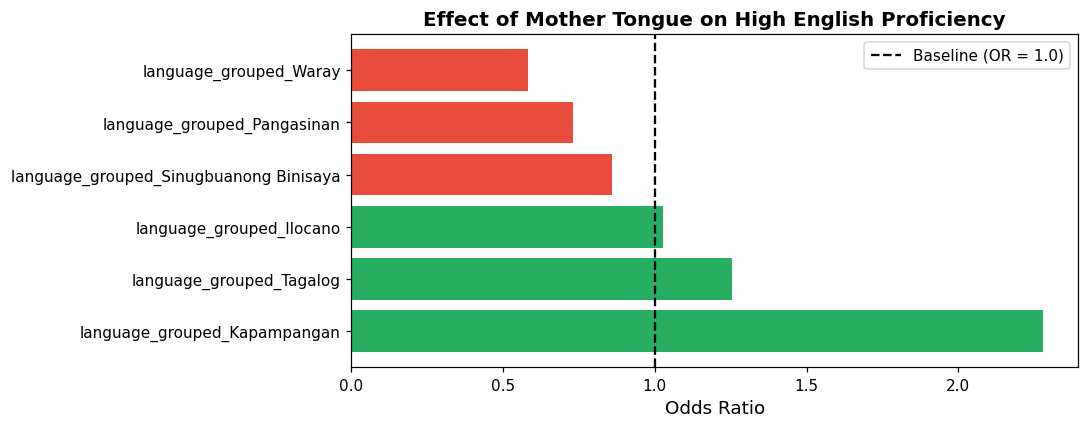

MODEL 2: STRUGGLING READER RATE ANALYSIS
Original Class Distribution (Before Resampling):
is_high_performing
Critical (0)           4411
High-Performing (1)    1682
Name: count, dtype: int64
--------------------------------------------------
MODEL PERFORMANCE: HIGH-PERFORMING SCHOOLS (≤30% Struggling)
Overall Accuracy: 61.44%

Classification Report:
                         precision    recall  f1-score   support

Not High Performing (0)     0.7594    0.6837    0.7196       882
    High Performing (1)     0.3435    0.4332    0.3832       337

               accuracy                         0.6144      1219
              macro avg     0.5515    0.5585    0.5514      1219
           weighted avg     0.6445    0.6144    0.6266      1219

STRONGEST PREDICTORS OF HIGH PERFORMING PROFICIENCY

 Interpretation Guide:
   • OR > 1.0 = INCREASES chance of being High-Performing (Green)
   • OR < 1.0 = DECREASES chance / Risk Factor (Red)
   • OR = 1.0 = No effect

                                 

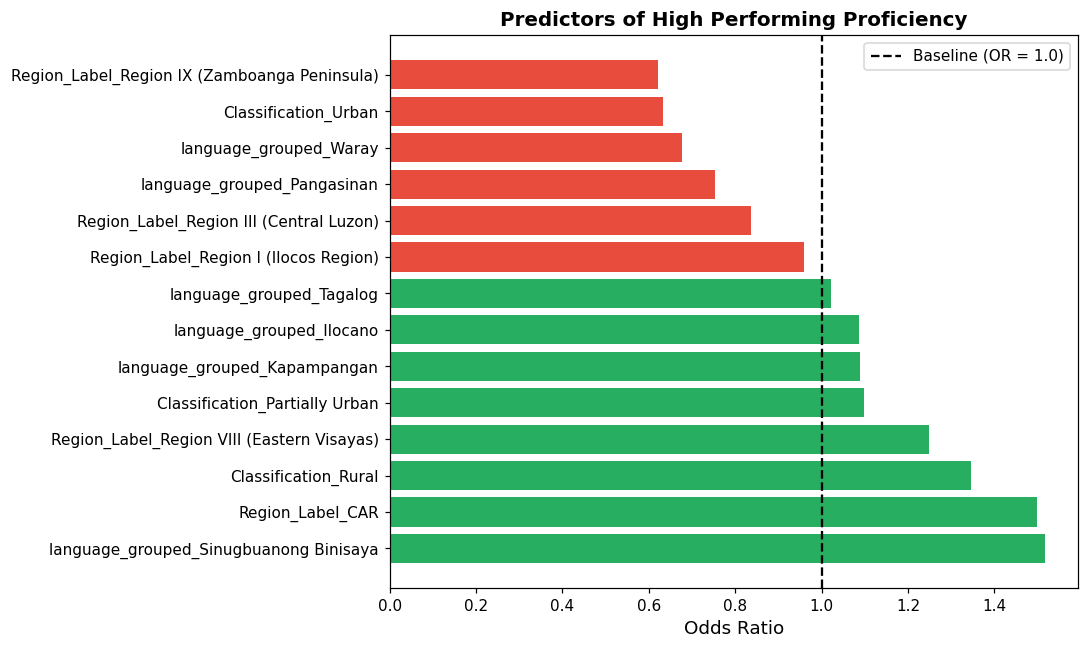

MODEL 3: HIGH ENGLISH PROFICIENCY ANALYSIS (FULL MODEL)
MODEL PERFORMANCE: HIGH GRADE 3 ENGLISH PROFICIENCY
Overall Accuracy: 54.41%

Classification Report:
                      precision    recall  f1-score   support

Not High English (0)     0.5942    0.5117    0.5499       641
    High English (1)     0.5000    0.5829    0.5383       537

            accuracy                         0.5441      1178
           macro avg     0.5471    0.5473    0.5441      1178
        weighted avg     0.5513    0.5441    0.5446      1178

STRONGEST PREDICTORS OF HIGH ENGLISH PROFICIENCY

 Interpretation Guide:
   • OR > 1.0 = INCREASES chance of being High-Performing (Green)
   • OR < 1.0 = DECREASES chance / Risk Factor (Red)
   • OR = 1.0 = No effect

                                     Feature  Coefficient  Odds_Ratio
                language_grouped_Kapampangan       0.4855      1.6251
     Region_Label_Region III (Central Luzon)       0.3763      1.4568
                        Classification_

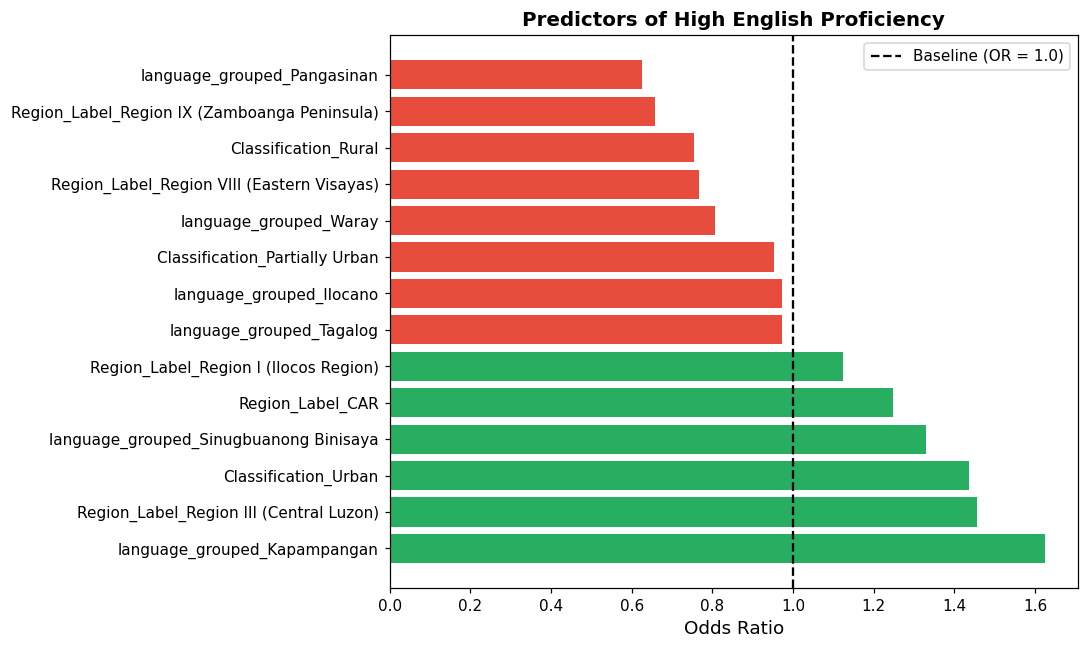

MODEL 4: HIGH FILIPINO PROFICIENCY ANALYSIS
Schools used: 6,028
Original Class Distribution:
is_high_filipino
Not High Filipino (0)    3351
High Filipino (1)        2677
Name: count, dtype: int64
--------------------------------------------------
MODEL PERFORMANCE: HIGH GRADE 3 FILIPINO PROFICIENCY
Overall Accuracy: 58.62%

Classification Report:
                       precision    recall  f1-score   support

Not High Filipino (0)     0.5945    0.8030    0.6832       670
    High Filipino (1)     0.5615    0.3153    0.4038       536

             accuracy                         0.5862      1206
            macro avg     0.5780    0.5591    0.5435      1206
         weighted avg     0.5798    0.5862    0.5590      1206

STRONGEST PREDICTORS OF HIGH FILIPINO PROFICIENCY

 Interpretation Guide:
   • OR > 1.0 = INCREASES chance of being High-Performing (Green)
   • OR < 1.0 = DECREASES chance / Risk Factor (Red)
   • OR = 1.0 = No effect

                                     Feature  Coef

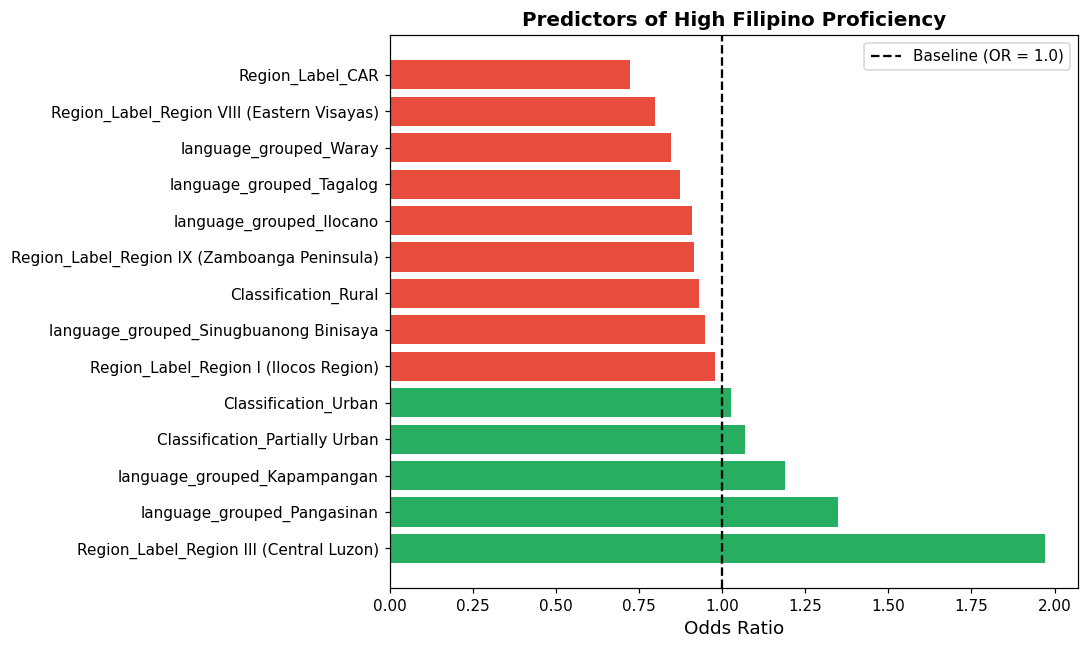

ALL FOUR MODELS COMPLETED SUCCESSFULLY!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings('ignore')

# ==========================================
# HELPER FUNCTIONS
# ==========================================

def prepare_data(df, target_col, target_label, rate_col, threshold=0.20):
    """Prepare data for a specific target variable."""
    # Filter schools with valid data
    df_temp = df[df[target_col] > 0].copy()

    # Calculate rate
    df_temp['rate'] = df_temp[rate_col] / df_temp[target_col]

    # Create target variable
    target_name = f'is_high_{target_label.lower()}'
    df_temp[target_name] = (df_temp['rate'] >= threshold).astype(int)

    # Remove 'Not Reported' classifications
    df_temp = df_temp[df_temp['Classification'] != 'Not Reported'].copy()

    # Group rare languages
    lang_counts = df_temp['language'].value_counts()
    threshold_lang = 30
    top_langs = lang_counts[lang_counts >= threshold_lang].index
    df_temp['language_grouped'] = df_temp['language'].apply(
        lambda x: x if x in top_langs else 'Other Minority Languages'
    )

    # Exclude 'Other Minority Languages'
    model_df = df_temp[df_temp['language_grouped'] != 'Other Minority Languages'].copy()
    model_df = model_df.dropna(subset=[target_name, 'Classification', 'language_grouped', 'Region_Label']).copy()

    return model_df, target_name

def run_mt_only_model(model_df, target_name, target_label, title):
    """Run logistic regression model using ONLY Mother Tongue as the predictor."""
    # Define features - ONLY language_grouped (Region and Classification are excluded)
    categorical_features = ['language_grouped']

    X = model_df[categorical_features]
    y = model_df[target_name]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # Resample to handle class imbalance
    sampler = RandomUnderSampler(random_state=42)
    X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

    # Build pipeline (Only categorical encoding for language)
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ]
    )

    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ])

    # Train
    model_pipeline.fit(X_train_resampled, y_train_resampled)

    # Evaluate
    y_pred = model_pipeline.predict(X_test)

    print("=" * 60)
    print(f"MODEL PERFORMANCE: {title}")
    print("=" * 60)
    print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
    print("Classification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=[f'Not High {target_label} (0)', f'High {target_label} (1)'],
        digits=4
    ))

    # Extract odds ratios
    cat_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

    coefficients = model_pipeline.named_steps['classifier'].coef_[0]
    odds_ratios = np.exp(coefficients)

    odds_df = pd.DataFrame({
        'Feature': cat_feature_names,
        'Coefficient': np.round(coefficients, 4),
        'Odds_Ratio': np.round(odds_ratios, 4)
    }).sort_values(by='Odds_Ratio', ascending=False).reset_index(drop=True)

    print("=" * 60)
    print(f"ODDS RATIOS: EFFECT OF MOTHER TONGUE ON HIGH {target_label.upper()}")
    print("=" * 60)
    print("\n Interpretation Guide:")
    print("   * OR > 1.0 = INCREASES chance of High English Proficiency")
    print("   * OR < 1.0 = DECREASES chance / Risk Factor")
    print("   * OR = 1.0 = Baseline language (Reference group)\n")
    print(odds_df.to_string(index=False))
    print("\n")

    # Visualization - Show ALL languages since there are only a few
    fig, ax = plt.subplots(figsize=(10, max(4, len(odds_df) * 0.5)))
    colors = ['#27ae60' if x > 1 else '#e74c3c' for x in odds_df['Odds_Ratio']]
    ax.barh(odds_df['Feature'], odds_df['Odds_Ratio'], color=colors)
    ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='Baseline (OR = 1.0)')
    ax.set_xlabel('Odds Ratio', fontsize=12)
    ax.set_title(f'Effect of Mother Tongue on High {target_label} Proficiency', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return odds_df

def run_full_model(model_df, target_name, target_label, title):
    """Run full logistic regression model with all features."""
    # Define features
    categorical_features = ['Classification', 'language_grouped', 'Region_Label']
    numerical_features = [col for col in ['PC1', 'PC2'] if col in model_df.columns]

    X = model_df[categorical_features + numerical_features]
    y = model_df[target_name]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # Resample
    sampler = RandomUnderSampler(random_state=42)
    X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

    # Build pipeline
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
    if numerical_features:
        transformers.append(('num', StandardScaler(), numerical_features))

    preprocessor = ColumnTransformer(transformers=transformers)

    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ])

    # Train
    model_pipeline.fit(X_train_resampled, y_train_resampled)

    # Evaluate
    y_pred = model_pipeline.predict(X_test)

    print("=" * 60)
    print(f"MODEL PERFORMANCE: {title}")
    print("=" * 60)
    print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
    print("Classification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=[f'Not High {target_label} (0)', f'High {target_label} (1)'],
        digits=4
    ))

    # Extract odds ratios
    cat_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
    all_feature_names = list(cat_feature_names) + numerical_features

    coefficients = model_pipeline.named_steps['classifier'].coef_[0]
    odds_ratios = np.exp(coefficients)

    odds_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Coefficient': np.round(coefficients, 4),
        'Odds_Ratio': np.round(odds_ratios, 4)
    }).sort_values(by='Odds_Ratio', ascending=False).reset_index(drop=True)

    print("=" * 60)
    print(f"STRONGEST PREDICTORS OF HIGH {target_label.upper()} PROFICIENCY")
    print("=" * 60)
    print("\n Interpretation Guide:")
    print("   • OR > 1.0 = INCREASES chance of being High-Performing (Green)")
    print("   • OR < 1.0 = DECREASES chance / Risk Factor (Red)")
    print("   • OR = 1.0 = No effect\n")
    print(odds_df.to_string(index=False))
    print("\n")

    # Visualization
    top_predictors = pd.concat([odds_df.head(8), odds_df.tail(8)]).drop_duplicates()
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#27ae60' if x > 1 else '#e74c3c' for x in top_predictors['Odds_Ratio']]
    ax.barh(top_predictors['Feature'], top_predictors['Odds_Ratio'], color=colors)
    ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='Baseline (OR = 1.0)')
    ax.set_xlabel('Odds Ratio', fontsize=12)
    ax.set_title(f'Predictors of High {target_label} Proficiency', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return odds_df

# ==========================================
# MODEL 1: MOTHER TONGUE ONLY (NEW)
# ==========================================
print("=" * 80)
print("MODEL 1: ISOLATING MOTHER TONGUE EFFECT ON HIGH ENGLISH PROFICIENCY")
print("=" * 80)

# Prepare English data first
model_df_eng, target_eng = prepare_data(df, 'g3_eng_total', 'English', 'g3_eng_at_grade_level', 0.20)
print(f"Schools used: {len(model_df_eng):,}")
print("Original Class Distribution:")
print(model_df_eng[target_eng].value_counts().rename({1: 'High English (1)', 0: 'Not High English (0)'}))
print("-" * 50)

# Run Mother Tongue-only model
run_mt_only_model(model_df_eng, target_eng, 'English', 'MOTHER TONGUE EFFECT ON HIGH ENGLISH PROFICIENCY')

# ==========================================
# MODEL 2: STRUGGLING READER RATE (30% threshold)
# ==========================================
print("=" * 80)
print("MODEL 2: STRUGGLING READER RATE ANALYSIS")
print("=" * 80)

# Calculate Struggling-Reader Rate
df['struggling_reader_rate'] = df['school_low_emerging_percent'] + df['school_high_emerging_percent']

# Target: 1 = High-Performing (<= 30% struggling), 0 = Critical (> 30% struggling)
df['is_high_performing'] = (df['struggling_reader_rate'] <= 0.30).astype(int)

# Remove 'Not Reported' classifications
df_clean = df[df['Classification'] != 'Not Reported'].copy()

# Group rare languages
lang_counts = df_clean['language'].value_counts()
threshold_lang = 30
top_langs = lang_counts[lang_counts >= threshold_lang].index
df_clean['language_grouped'] = df_clean['language'].apply(
    lambda x: x if x in top_langs else 'Other Minority Languages'
)

# Exclude 'Other Minority Languages'
model_df_sr = df_clean[df_clean['language_grouped'] != 'Other Minority Languages'].copy()
model_df_sr = model_df_sr.dropna(subset=['is_high_performing', 'Classification', 'language_grouped', 'Region_Label']).copy()

print(f"Original Class Distribution (Before Resampling):")
print(model_df_sr['is_high_performing'].value_counts().rename({1: 'High-Performing (1)', 0: 'Critical (0)'}))
print("-" * 50)

# Run full model
run_full_model(model_df_sr, 'is_high_performing', 'Performing', 'HIGH-PERFORMING SCHOOLS (≤30% Struggling)')

# ==========================================
# MODEL 3: HIGH ENGLISH PROFICIENCY (Full Model)
# ==========================================
print("=" * 80)
print("MODEL 3: HIGH ENGLISH PROFICIENCY ANALYSIS (FULL MODEL)")
print("=" * 80)

# Run full model with all features
run_full_model(model_df_eng, target_eng, 'English', 'HIGH GRADE 3 ENGLISH PROFICIENCY')

# ==========================================
# MODEL 4: HIGH FILIPINO PROFICIENCY
# ==========================================
print("=" * 80)
print("MODEL 4: HIGH FILIPINO PROFICIENCY ANALYSIS")
print("=" * 80)

model_df_fil, target_fil = prepare_data(df, 'g3_fil_total', 'Filipino', 'g3_fil_at_grade_level', 0.20)
print(f"Schools used: {len(model_df_fil):,}")
print("Original Class Distribution:")
print(model_df_fil[target_fil].value_counts().rename({1: 'High Filipino (1)', 0: 'Not High Filipino (0)'}))
print("-" * 50)

# Run full model
run_full_model(model_df_fil, target_fil, 'Filipino', 'HIGH GRADE 3 FILIPINO PROFICIENCY')

print("=" * 80)
print("ALL FOUR MODELS COMPLETED SUCCESSFULLY!")
print("=" * 80)